In [1]:
# Setup and imports
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import cv2
import pickle
import importlib
import os
import datetime
import glob
import time

# Import orig_clases - vehicle classes we want to avoid
import consts
importlib.reload(consts)
orig_clases = consts.orig_clases

from aruco_pose import get_camera_angles_from_frame
from capture_utils_v2 import CaptureSystem

tt = lambda x: torch.tensor(cv2.cvtColor(x, cv2.COLOR_BGR2RGB)/255.).permute(2,0,1).float()

print(f"Original vehicle classes to avoid: {orig_clases.tolist()}")
%matplotlib inline

c:\Users\danny\anaconda3\envs\py310\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Camera Matrix:
[[1.04739831e+03 0.00000000e+00 3.24036999e+02]
 [0.00000000e+00 9.50491793e+02 3.23897832e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Distortion Coefficients: [ 2.60138074e-01 -4.37871352e+00  3.56370583e-02 -2.58297180e-03
  2.21970709e+01]
Original vehicle classes to avoid: [817, 705, 609, 586, 436, 627, 468, 621, 803, 407, 408, 751, 717, 866, 661, 864]


In [2]:
# Initialize capture system
system = CaptureSystem()
cap = system.cap
print("✓ Camera initialized")

Pixel format set to RGB8
IC4 Grabber and Sink initialized.
✓ Camera initialized


In [3]:
# Load calibration state
with open("capture_system_state.pkl", "rb") as f:
    system.orig_proj_corners, system.corners_img_proj, system.orig_img = pickle.load(f)
print("✓ Calibration state loaded")

✓ Calibration state loaded


In [4]:
# Load all classifiers for evaluation
print("Loading classifiers...")

# Ensemble v1 classifier (Inception, ResNet, VGG, ViT, DINOv2)
import classfier_ensemble as ensemble_v1
ensemble_v1_weights = ensemble_v1.weights
print("✓ Ensemble v1 loaded (Inception, ResNet, VGG, ViT, DINOv2)")

# Ensemble v2 classifier (ConvNeXt, EfficientNet, MobileNet, Swin)
import classfier_ensemble_v2 as ensemble_v2
ensemble_v2_weights = ensemble_v2.weights
print("✓ Ensemble v2 loaded (ConvNeXt, EfficientNet, MobileNet, Swin)")

# DINOv2 standalone classifier
import classfier_dino as dino
dino_weights = dino.weights
print("✓ DINOv2 standalone classifier loaded")

categories = ensemble_v1_weights.meta["categories"]
print(f"\n✓ All classifiers ready for evaluation")

Loading classifiers...
Loading ensemble models...


Using cache found in C:\Users\danny/.cache\torch\hub\facebookresearch_dinov2_main
A matching Triton is not available, some optimizations will not be enabled
Traceback (most recent call last):
  File "c:\Users\danny\anaconda3\envs\py310\lib\site-packages\xformers\__init__.py", line 57, in _is_triton_available
    import triton  # noqa
ModuleNotFoundError: No module named 'triton'
C:\Users\danny/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
C:\Users\danny/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:27: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
C:\Users\danny/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")


✓ All models loaded successfully!
  - Inception V3
  - ResNet18
  - VGG16
  - ViT-B/16
  - DINOv2

✓ Ensemble classifier ready!
  Main function: predict_raw(image)
  Alternatives: predict_raw_weighted(image, weights_dict)
               predict_raw_per_model(image)
               ensemble_predict(image)
✓ Ensemble v1 loaded (Inception, ResNet, VGG, ViT, DINOv2)
Loading ensemble v2 models...
✓ All models loaded successfully!
  - ConvNeXt Base
  - EfficientNet B0
  - MobileNetV3 Large
  - Swin Transformer Base

✓ Ensemble classifier v2 ready!
  Main function: predict_raw(image)
  Alternatives: predict_raw_weighted(image, weights_dict)
               predict_raw_per_model(image)
               ensemble_predict(image)
✓ Ensemble v2 loaded (ConvNeXt, EfficientNet, MobileNet, Swin)


Using cache found in C:\Users\danny/.cache\torch\hub\facebookresearch_dinov2_main


✓ DINOv2 standalone classifier loaded

✓ All classifiers ready for evaluation


## Configure Patch Folders

Set the paths to the folders containing patches.

In [5]:
# ============================================
# CONFIGURE THESE PATHS
# ============================================

# Folder containing CAPAA patches (PNG/JPG files)
capaa_folder = r"C:\git\CAPAA\src\python\data\setups\jeep8\prj\adv\CAPAA_PCNet_l1+ssim_500_24_2000\camdE_caml2\5\classifier_all"

# Folder containing Best Patch patterns (PNG/JPG files)
best_patch_folder = r"C:\git\PhysicalAdverserialProj\results\ensamble_classifier_2025-12-24_21_20_top_patches"

# Capture delay in seconds (time to wait after projecting before capturing)
CAPTURE_DELAY = 1.0

# Multi-pose capture settings
MULTI_POSE = True  # Set to True to capture from multiple camera poses
NUM_POSES = 4       # Number of poses to capture (only used if MULTI_POSE=True)
NUM_CAPTURES = 10   # Number of frames to capture per patch per pose

# RUN_ALL mode: Run both approaches sequentially in one session
# When True: Press 's' once and both Best Patch then CAPAA run under the same pose
RUN_ALL = True  # Set to True to run both approaches in sequence per pose

# File extensions to look for
EXTENSIONS = ['*.png', '*.jpg', '*.jpeg']

# Projector setup info (same as in complete_attack_v2.ipynb)
PRJ_SCREEN_SZ = (1920, 1080)  # Projector screen resolution
PRJ_OFFSET = (2560, 0)        # Offset to move window to projector screen
PRJ_WINDOW_NAME = "Projector"

print(f"CAPAA folder: {capaa_folder}")
print(f"Best Patch folder: {best_patch_folder}")
print(f"Capture delay: {CAPTURE_DELAY}s")
print(f"Multi-pose: {MULTI_POSE} ({NUM_POSES} poses)" if MULTI_POSE else f"Multi-pose: {MULTI_POSE} (single pose)")
print(f"Frames per capture: {NUM_CAPTURES}")
print(f"RUN_ALL mode: {RUN_ALL} (both approaches in sequence)" if RUN_ALL else f"RUN_ALL mode: {RUN_ALL} (separate runs)")
print(f"Projector: {PRJ_SCREEN_SZ[0]}x{PRJ_SCREEN_SZ[1]} at offset {PRJ_OFFSET}")

CAPAA folder: C:\git\CAPAA\src\python\data\setups\jeep8\prj\adv\CAPAA_PCNet_l1+ssim_500_24_2000\camdE_caml2\5\classifier_all
Best Patch folder: C:\git\PhysicalAdverserialProj\results\ensamble_classifier_2025-12-24_21_20_top_patches
Capture delay: 1.0s
Multi-pose: True (4 poses)
Frames per capture: 10
RUN_ALL mode: True (both approaches in sequence)
Projector: 1920x1080 at offset (2560, 0)


In [6]:
# Load patch files from folders
def get_patch_files(folder, extensions=EXTENSIONS):
    """Get all image files from a folder."""
    files = []
    for ext in extensions:
        files.extend(glob.glob(os.path.join(folder, ext)))
    return sorted(files)

capaa_patches = get_patch_files(capaa_folder)
best_patch_patches = get_patch_files(best_patch_folder)

print(f"\nFound {len(capaa_patches)} CAPAA patches:")
for p in capaa_patches[:5]:
    print(f"  - {os.path.basename(p)}")
if len(capaa_patches) > 5:
    print(f"  ... and {len(capaa_patches) - 5} more")

print(f"\nFound {len(best_patch_patches)} Best Patch files:")
for p in best_patch_patches[:5]:
    print(f"  - {os.path.basename(p)}")
if len(best_patch_patches) > 5:
    print(f"  ... and {len(best_patch_patches) - 5} more")


Found 11 CAPAA patches:
  - img_0001.png
  - img_0002.png
  - img_0003.png
  - img_0004.png
  - img_0005.png
  ... and 6 more

Found 17 Best Patch files:
  - 11_0.45.png
  - 12_0.36.png
  - 14_0.45.png
  - 15_0.27.png
  - 17_0.54.png
  ... and 12 more


## Batch Capture Function

In [7]:
def init_projector_window(window_name, screen_sz, offset):
    """
    Initialize a fullscreen projector window using cv2 (similar to init_prj_window).
    
    Args:
        window_name: Name for the window
        screen_sz: (width, height) of projector screen
        offset: (x, y) offset to move window to projector
    """
    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
    cv2.moveWindow(window_name, offset[0], offset[1])
    cv2.setWindowProperty(window_name, cv2.WND_PROP_FULLSCREEN, cv2.WINDOW_FULLSCREEN)
    # Create black image initially
    black_img = np.zeros((screen_sz[1], screen_sz[0], 3), dtype=np.uint8)
    cv2.imshow(window_name, black_img)
    cv2.waitKey(1)
    return window_name


def project_image_cv2(window_name, img, screen_sz):
    """
    Project an image to the cv2 projector window, scaled to fit.
    
    Args:
        window_name: Name of the projector window
        img: Image to project (BGR format)
        screen_sz: (width, height) of projector screen
    """
    # Resize image to fit projector screen while maintaining aspect ratio
    h, w = img.shape[:2]
    scale = min(screen_sz[0] / w, screen_sz[1] / h)
    new_w, new_h = int(w * scale), int(h * scale)
    
    # Create black background
    display_img = np.zeros((screen_sz[1], screen_sz[0], 3), dtype=np.uint8)
    
    # Resize and center the image
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    x_offset = (screen_sz[0] - new_w) // 2
    y_offset = (screen_sz[1] - new_h) // 2
    display_img[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized
    
    cv2.imshow(window_name, display_img)
    cv2.waitKey(1)


def capture_multiple_frames(cap, num_frames=10):
    """
    Capture multiple frames for stability analysis.
    
    Args:
        cap: OpenCV VideoCapture object
        num_frames: Number of frames to capture
    
    Returns:
        List of captured frames (uint8)
    """
    frames = []
    for _ in range(num_frames):
        ret, frame = cap.read()
        if ret:
            frames.append(frame.copy())
        time.sleep(0.05)  # Small delay between captures (~20 FPS)
    
    return frames


def get_live_classification(frame, categories):
    """
    Get live classification from DINOv2 and Ensemble V2.
    
    Args:
        frame: BGR frame from camera
        categories: List of category names
    
    Returns:
        Dictionary with classification results:
        - dino_class: DINOv2 predicted class name
        - dino_prob: DINOv2 confidence probability
        - dino_success: True if not a vehicle class
        - v2_class: Ensemble V2 predicted class name
        - v2_prob: Ensemble V2 confidence probability
        - v2_success: True if not a vehicle class
    """
    # Convert frame to tensor
    img_tensor = tt(frame).unsqueeze(0).cuda()
    
    with torch.no_grad():
        # DINOv2 prediction
        dino_probs = dino.predict_raw(img_tensor)
        dino_pred_idx = dino_probs[0].argmax().item()
        dino_prob = dino_probs[0, dino_pred_idx].item()
        dino_class = categories[dino_pred_idx]
        dino_success = dino_pred_idx not in orig_clases.tolist()
        
        # Ensemble V2 joint prediction
        v2_probs = ensemble_v2.predict_raw(img_tensor)
        v2_pred_idx = v2_probs[0].argmax().item()
        v2_prob = v2_probs[0, v2_pred_idx].item()
        v2_class = categories[v2_pred_idx]
        v2_success = v2_pred_idx not in orig_clases.tolist()
    
    return {
        'dino_class': dino_class,
        'dino_prob': dino_prob,
        'dino_success': dino_success,
        'v2_class': v2_class,
        'v2_prob': v2_prob,
        'v2_success': v2_success
    }


def draw_classification_overlay(display_frame, classification):
    """
    Draw classification results at the bottom of the display frame.
    
    Args:
        display_frame: Frame to draw on (modified in place)
        classification: Dictionary from get_live_classification()
    """
    frame_height = display_frame.shape[0]
    
    # Draw background for classification info at bottom
    y_start = frame_height - 60
    cv2.rectangle(display_frame, (0, y_start), (display_frame.shape[1], frame_height), (30, 30, 30), -1)
    
    # DINOv2 classification
    dino_color = (0, 255, 0) if classification['dino_success'] else (0, 0, 255)
    dino_text = f"DINO: {classification['dino_class'][:25]} ({classification['dino_prob']*100:.1f}%)"
    cv2.putText(display_frame, dino_text, (10, y_start + 22), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, dino_color, 2)
    
    # Ensemble V2 classification
    v2_color = (0, 255, 0) if classification['v2_success'] else (0, 0, 255)
    v2_text = f"V2 Ens: {classification['v2_class'][:25]} ({classification['v2_prob']*100:.1f}%)"
    cv2.putText(display_frame, v2_text, (10, y_start + 47), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, v2_color, 2)


def batch_capture_patches(cap, system, patch_files, approach_name, delay=1.0, 
                          window_name="Batch Capture", use_cv2_projector=False,
                          prj_screen_sz=None, prj_offset=None, num_captures=10,
                          multi_pose=False, num_poses=1):
    """
    Capture frames for multiple patches. Press 's' to START capturing.
    Captures multiple frames per patch for robust classification.
    Shows live DINOv2 and Ensemble V2 classification on camera preview.
    
    Args:
        cap: OpenCV VideoCapture object
        system: CaptureSystem for projection (used for Best Patch)
        patch_files: List of patch file paths
        approach_name: Name of the approach (for display)
        delay: Seconds to wait after projecting before capturing
        window_name: Name for the camera display window
        use_cv2_projector: If True, use cv2 fullscreen window (for CAPAA)
        prj_screen_sz: Projector screen size (width, height)
        prj_offset: Projector window offset (x, y)
        num_captures: Number of frames to capture per patch per pose (default: 10)
        multi_pose: If True, capture from multiple poses (default: False)
        num_poses: Number of poses to capture from when multi_pose=True (default: 1)
    
    Returns:
        List of captured data with frames (list), pose, and patch info
        When multi_pose=True, each entry includes 'pose_idx' field
    """
    captured_data = []
    prj_window = None
    
    # Determine actual number of poses
    actual_num_poses = num_poses if multi_pose else 1
    
    print(f"\n{'='*60}")
    print(f"BATCH CAPTURE: {approach_name}")
    print(f"{'='*60}")
    print(f"Found {len(patch_files)} patches to process")
    print(f"Delay per patch: {delay}s")
    print(f"Frames per patch per pose: {num_captures}")
    if multi_pose:
        print(f"Multi-pose mode: ENABLED ({num_poses} poses)")
        print(f"Total frames to capture: {len(patch_files) * num_captures * num_poses}")
    else:
        print(f"Multi-pose mode: DISABLED (single pose)")
        print(f"Total frames to capture: {len(patch_files) * num_captures}")
    print(f"Projection mode: {'CV2 Fullscreen' if use_cv2_projector else 'CaptureSystem'}")
    print(f"Live classification: DINOv2 + Ensemble V2")
    print(f"\nPress 's' to START capturing each pose")
    print(f"Press 'p' to PREVIEW a random patch (no capture)")
    print(f"Press 'q' to QUIT/abort")
    print(f"{'='*60}\n")
    
    # Create camera preview window on main display (position at top-left of primary screen)
    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
    cv2.moveWindow(window_name, 50, 50)  # Position on main display
    cv2.resizeWindow(window_name, 1280, 720)
    
    # Show initial camera frame before creating projector window
    print("Initializing camera preview...")
    for _ in range(10):  # Read a few frames to warm up camera
        ret, frame = cap.read()
        if ret:
            cv2.imshow(window_name, frame)
            cv2.waitKey(30)
    
    # Initialize projector window if using cv2 mode
    if use_cv2_projector and prj_screen_sz and prj_offset:
        prj_window = init_projector_window(PRJ_WINDOW_NAME, prj_screen_sz, prj_offset)
        # Bring camera preview back to focus
        cv2.setWindowProperty(window_name, cv2.WND_PROP_TOPMOST, 1)
        cv2.waitKey(1)
        cv2.setWindowProperty(window_name, cv2.WND_PROP_TOPMOST, 0)
    
    # Loop through each pose
    for pose_idx in range(actual_num_poses):
        pose_label = f"Pose {pose_idx + 1}/{actual_num_poses}" if multi_pose else "Single Pose"
        
        # Wait for 's' key to start this pose
        print(f"\n--- {pose_label} ---")
        print("Waiting for 's' key to start... Press 'p' to preview random patch.")
        started = False
        last_classification_time = 0
        cached_classification = None
        preview_patch_name = None  # Track currently previewed patch
        
        while not started:
            ret, frame = cap.read()
            if not ret:
                continue
            
            display_frame = frame.copy()
            cv2.rectangle(display_frame, (0, 0), (display_frame.shape[1], 110), (40, 40, 40), -1)
            
            if multi_pose:
                cv2.putText(display_frame, f"{approach_name} - {pose_label}", 
                            (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 255), 2)
                cv2.putText(display_frame, f"'s'=START | 'p'=Preview | 'q'=Quit", 
                            (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
            else:
                cv2.putText(display_frame, f"{approach_name} - 's'=START | 'p'=Preview | 'q'=Quit", 
                            (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 255), 2)
            
            # Show preview patch name if one is being previewed
            if preview_patch_name:
                cv2.putText(display_frame, f"Preview: {preview_patch_name[:40]}", 
                            (10, 60 if not multi_pose else 90), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 165, 0), 2)
                info_y = 90 if not multi_pose else 110
            else:
                info_y = 60 if not multi_pose else 90
            
            cv2.putText(display_frame, f"Patches: {len(patch_files)} | Frames/patch: {num_captures}", 
                        (10, info_y if not preview_patch_name else info_y + 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (200, 200, 200), 2)
            
            # ArUco pose
            pose_result = get_camera_angles_from_frame(frame)
            if pose_result['found']:
                pose_text = f"Angle: {pose_result['angle']:.1f} deg | Dist: {pose_result['distance_m']:.2f}m"
                cv2.putText(display_frame, pose_text, (10, 140), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
            else:
                cv2.putText(display_frame, "ArUco NOT DETECTED", (10, 140), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
            
            # Live classification (update every 0.2 seconds to avoid lag)
            current_time = time.time()
            if current_time - last_classification_time > 0.2:
                cached_classification = get_live_classification(frame, categories)
                last_classification_time = current_time
            
            if cached_classification:
                draw_classification_overlay(display_frame, cached_classification)
            
            cv2.imshow(window_name, display_frame)
            key = cv2.waitKey(30) & 0xFF
            
            if key == ord('s'):
                started = True
                print(f"\n✓ Starting capture for {pose_label}...\n")
            elif key == ord('p'):
                # Preview a random patch without capturing
                import random
                random_patch_path = random.choice(patch_files)
                preview_patch_name = os.path.basename(random_patch_path)
                print(f"  📺 Preview: {preview_patch_name}")
                
                try:
                    preview_img = cv2.imread(random_patch_path)
                    if preview_img is not None:
                        if use_cv2_projector and prj_window:
                            project_image_cv2(prj_window, preview_img, prj_screen_sz)
                        else:
                            preview_img_rgb = cv2.cvtColor(preview_img, cv2.COLOR_BGR2RGB)
                            system.plot_on_screen(preview_img_rgb)
                except Exception as e:
                    print(f"  ✗ Preview error: {e}")
            elif key == ord('q'):
                print("\n✗ Capture cancelled")
                cv2.destroyWindow(window_name)
                if prj_window:
                    cv2.destroyWindow(prj_window)
                return captured_data
        
        # Process each patch for this pose
        for patch_idx, patch_path in enumerate(patch_files):
            patch_name = os.path.basename(patch_path)
            print(f"[{pose_label}] [{patch_idx+1}/{len(patch_files)}] Processing: {patch_name}")
            
            # Load patch image
            try:
                patch_img = cv2.imread(patch_path)
                if patch_img is None:
                    print(f"  ✗ Failed to load image, skipping")
                    continue
                
                # Project the patch
                if use_cv2_projector and prj_window:
                    # Use cv2 fullscreen window for CAPAA
                    project_image_cv2(prj_window, patch_img, prj_screen_sz)
                else:
                    # Use CaptureSystem for Best Patch
                    patch_img_rgb = cv2.cvtColor(patch_img, cv2.COLOR_BGR2RGB)
                    system.plot_on_screen(patch_img_rgb)
                    
            except Exception as e:
                print(f"  ✗ Error projecting: {e}")
                continue
            
            # Wait for stabilization with live preview
            start_time = time.time()
            last_classification_time = 0
            cached_classification = None
            
            while (time.time() - start_time) < delay:
                ret, frame = cap.read()
                if not ret:
                    continue
                
                # Create display frame
                display_frame = frame.copy()
                remaining = delay - (time.time() - start_time)
                
                # Status bar (expanded height to fit classification)
                cv2.rectangle(display_frame, (0, 0), (display_frame.shape[1], 130), (40, 40, 40), -1)
                if multi_pose:
                    cv2.putText(display_frame, f"{approach_name} - {pose_label}", 
                                (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
                else:
                    cv2.putText(display_frame, f"{approach_name} - Patch {patch_idx+1}/{len(patch_files)}", 
                                (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
                cv2.putText(display_frame, f"Patch {patch_idx+1}/{len(patch_files)}: {patch_name}", 
                            (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 200, 200), 1)
                cv2.putText(display_frame, f"Capturing in: {remaining:.1f}s", 
                            (10, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
                
                # ArUco pose
                pose_result = get_camera_angles_from_frame(frame)
                if pose_result['found']:
                    pose_text = f"Angle: {pose_result['angle']:.1f} deg | Dist: {pose_result['distance_m']:.2f}m"
                    cv2.putText(display_frame, pose_text, (10, 120), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
                else:
                    cv2.putText(display_frame, "ArUco NOT DETECTED", (10, 120), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
                
                # Live classification (update every 0.2 seconds to avoid lag)
                current_time = time.time()
                if current_time - last_classification_time > 0.2:
                    cached_classification = get_live_classification(frame, categories)
                    last_classification_time = current_time
                
                if cached_classification:
                    draw_classification_overlay(display_frame, cached_classification)
                
                cv2.imshow(window_name, display_frame)
                key = cv2.waitKey(30) & 0xFF
                if key == ord('q'):
                    print("\n✗ Capture aborted by user")
                    cv2.destroyWindow(window_name)
                    if prj_window:
                        cv2.destroyWindow(prj_window)
                    return captured_data
            
            # Show "Capturing..." status
            ret, preview_frame = cap.read()
            if ret:
                display_frame = preview_frame.copy()
                cv2.rectangle(display_frame, (0, 0), (display_frame.shape[1], 100), (40, 40, 40), -1)
                cv2.putText(display_frame, f"Capturing {num_captures} frames...", 
                            (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 255), 2)
                cv2.imshow(window_name, display_frame)
                cv2.waitKey(1)
            
            # Capture multiple frames
            frames = capture_multiple_frames(cap, num_frames=num_captures)
            if len(frames) == 0:
                print(f"  ✗ Failed to capture frames")
                continue
            
            # Get pose from the first frame (should be consistent across all)
            pose_result = get_camera_angles_from_frame(frames[0])
            
            capture_entry = {
                'patch_idx': patch_idx,
                'patch_name': patch_name,
                'patch_path': patch_path,
                'frames': frames,  # List of all captured frames
                'num_frames': len(frames),
                'angle': pose_result['angle'] if pose_result['found'] else None,
                'distance': pose_result['distance_m'] if pose_result['found'] else None
            }
            
            # Add pose index if multi_pose mode
            if multi_pose:
                capture_entry['pose_idx'] = pose_idx
            
            captured_data.append(capture_entry)
            
            if pose_result['found']:
                print(f"  ✓ Captured {len(frames)} frames: Angle={pose_result['angle']:.1f}°, Dist={pose_result['distance_m']:.2f}m")
            else:
                print(f"  ⚠ Captured {len(frames)} frames (no ArUco detected)")
            
            # Brief flash to indicate capture complete
            flash_frame = frames[-1].copy() if frames else preview_frame.copy()
            cv2.rectangle(flash_frame, (0, 0), (flash_frame.shape[1], flash_frame.shape[0]), (0, 255, 0), 10)
            cv2.imshow(window_name, flash_frame)
            cv2.waitKey(100)
        
        # After completing all patches for this pose
        if multi_pose and pose_idx < actual_num_poses - 1:
            print(f"\n✓ {pose_label} complete!")
            print(f"   Adjust camera position for next pose...")
    
    cv2.destroyWindow(window_name)
    if prj_window:
        cv2.destroyWindow(prj_window)
    
    total_frames = sum(cap_data['num_frames'] for cap_data in captured_data)
    if multi_pose:
        print(f"\n✓ Batch capture complete: {len(patch_files)} patches × {actual_num_poses} poses = {len(captured_data)} captures, {total_frames} total frames")
    else:
        print(f"\n✓ Batch capture complete: {len(captured_data)} patches, {total_frames} total frames")
    return captured_data

## RUN_ALL Function (Combined Capture)

In [8]:
def batch_capture_all_approaches(cap, system, bp_patches, capaa_patches, 
                                   delay=1.0, num_captures=10, multi_pose=False, num_poses=1,
                                   prj_screen_sz=None, prj_offset=None):
    """
    Run both Best Patch and CAPAA approaches sequentially under the same camera pose.
    Press 's' once to start both approaches for that pose.
    
    Args:
        cap: OpenCV VideoCapture object
        system: CaptureSystem for projection
        bp_patches: List of Best Patch file paths
        capaa_patches: List of CAPAA patch file paths
        delay: Seconds to wait after projecting before capturing
        num_captures: Number of frames to capture per patch per pose
        multi_pose: If True, capture from multiple poses
        num_poses: Number of poses to capture
        prj_screen_sz: Projector screen size (width, height)
        prj_offset: Projector window offset (x, y)
    
    Returns:
        Tuple of (best_patch_captures, capaa_captures)
    """
    import random
    
    bp_captured_data = []
    capaa_captured_data = []
    prj_window = None
    window_name = "Combined Capture"
    
    actual_num_poses = num_poses if multi_pose else 1
    total_patches = len(bp_patches) + len(capaa_patches)
    
    print(f"\n{'='*70}")
    print(f"RUN_ALL MODE: Combined Batch Capture")
    print(f"{'='*70}")
    print(f"Best Patch: {len(bp_patches)} patches")
    print(f"CAPAA: {len(capaa_patches)} patches")
    print(f"Total patches per pose: {total_patches}")
    print(f"Delay per patch: {delay}s")
    print(f"Frames per patch: {num_captures}")
    if multi_pose:
        print(f"Multi-pose mode: ENABLED ({num_poses} poses)")
        print(f"Total frames: {total_patches * num_captures * num_poses}")
    else:
        print(f"Multi-pose mode: DISABLED (single pose)")
        print(f"Total frames: {total_patches * num_captures}")
    print(f"\nOrder: Best Patch → CAPAA")
    print(f"\nPress 's' to START both approaches for each pose")
    print(f"Press 'p' to PREVIEW a random patch")
    print(f"Press 'q' to QUIT/abort")
    print(f"{'='*70}\n")
    
    # Create camera preview window
    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
    cv2.moveWindow(window_name, 50, 50)
    cv2.resizeWindow(window_name, 1280, 720)
    
    # Warm up camera
    print("Initializing camera preview...")
    for _ in range(10):
        ret, frame = cap.read()
        if ret:
            cv2.imshow(window_name, frame)
            cv2.waitKey(30)
    
    # Initialize projector window
    if prj_screen_sz and prj_offset:
        prj_window = init_projector_window(PRJ_WINDOW_NAME, prj_screen_sz, prj_offset)
        cv2.setWindowProperty(window_name, cv2.WND_PROP_TOPMOST, 1)
        cv2.waitKey(1)
        cv2.setWindowProperty(window_name, cv2.WND_PROP_TOPMOST, 0)
    
    # Loop through poses
    for pose_idx in range(actual_num_poses):
        pose_label = f"Pose {pose_idx + 1}/{actual_num_poses}" if multi_pose else "Single Pose"
        
        # Wait for 's' key to start this pose
        print(f"\n{'='*50}")
        print(f"--- {pose_label} ---")
        print(f"{'='*50}")
        print("Waiting for 's' key to start... Press 'p' to preview.")
        
        started = False
        last_classification_time = 0
        cached_classification = None
        preview_patch_name = None
        all_patches = bp_patches + capaa_patches
        
        while not started:
            ret, frame = cap.read()
            if not ret:
                continue
            
            display_frame = frame.copy()
            cv2.rectangle(display_frame, (0, 0), (display_frame.shape[1], 130), (40, 40, 40), -1)
            
            cv2.putText(display_frame, f"RUN_ALL MODE - {pose_label}", 
                        (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 255), 2)
            cv2.putText(display_frame, f"'s'=START | 'p'=Preview | 'q'=Quit", 
                        (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
            
            if preview_patch_name:
                cv2.putText(display_frame, f"Preview: {preview_patch_name[:40]}", 
                            (10, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 165, 0), 2)
            
            cv2.putText(display_frame, f"Best Patch: {len(bp_patches)} | CAPAA: {len(capaa_patches)} | Frames: {num_captures}", 
                        (10, 120), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 200, 200), 2)
            
            # ArUco pose
            pose_result = get_camera_angles_from_frame(frame)
            if pose_result['found']:
                pose_text = f"Angle: {pose_result['angle']:.1f} deg | Dist: {pose_result['distance_m']:.2f}m"
                cv2.putText(display_frame, pose_text, (10, 150), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
            else:
                cv2.putText(display_frame, "ArUco NOT DETECTED", (10, 150), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
            
            # Live classification
            current_time = time.time()
            if current_time - last_classification_time > 0.2:
                cached_classification = get_live_classification(frame, categories)
                last_classification_time = current_time
            
            if cached_classification:
                draw_classification_overlay(display_frame, cached_classification)
            
            cv2.imshow(window_name, display_frame)
            key = cv2.waitKey(30) & 0xFF
            
            if key == ord('s'):
                started = True
                print(f"\n✓ Starting {pose_label}...\n")
            elif key == ord('p'):
                random_patch_path = random.choice(all_patches)
                preview_patch_name = os.path.basename(random_patch_path)
                is_bp = random_patch_path in bp_patches
                method = "Best Patch" if is_bp else "CAPAA"
                print(f"  📺 Preview ({method}): {preview_patch_name}")
                
                try:
                    preview_img = cv2.imread(random_patch_path)
                    if preview_img is not None:
                        if is_bp:
                            preview_img_rgb = cv2.cvtColor(preview_img, cv2.COLOR_BGR2RGB)
                            system.plot_on_screen(preview_img_rgb)
                        else:
                            project_image_cv2(prj_window, preview_img, prj_screen_sz)
                except Exception as e:
                    print(f"  ✗ Preview error: {e}")
            elif key == ord('q'):
                print("\n✗ Capture cancelled")
                cv2.destroyWindow(window_name)
                if prj_window:
                    cv2.destroyWindow(prj_window)
                return bp_captured_data, capaa_captured_data
        
        # ============================================
        # PHASE 1: Best Patch
        # ============================================
        print(f"\n--- PHASE 1: Best Patch ({len(bp_patches)} patches) ---")
        
        for patch_idx, patch_path in enumerate(bp_patches):
            patch_name = os.path.basename(patch_path)
            print(f"[Best Patch] [{patch_idx+1}/{len(bp_patches)}] {patch_name}")
            
            try:
                patch_img = cv2.imread(patch_path)
                if patch_img is None:
                    print(f"  ✗ Failed to load image")
                    continue
                
                patch_img_rgb = cv2.cvtColor(patch_img, cv2.COLOR_BGR2RGB)
                system.plot_on_screen(patch_img_rgb)
            except Exception as e:
                print(f"  ✗ Error: {e}")
                continue
            
            # Wait with live preview
            start_time = time.time()
            last_classification_time = 0
            cached_classification = None
            
            while (time.time() - start_time) < delay:
                ret, frame = cap.read()
                if not ret:
                    continue
                
                display_frame = frame.copy()
                remaining = delay - (time.time() - start_time)
                
                cv2.rectangle(display_frame, (0, 0), (display_frame.shape[1], 130), (40, 40, 40), -1)
                cv2.putText(display_frame, f"Best Patch - {pose_label}", 
                            (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 165, 0), 2)
                cv2.putText(display_frame, f"[{patch_idx+1}/{len(bp_patches)}] {patch_name}", 
                            (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 200, 200), 1)
                cv2.putText(display_frame, f"Capturing in: {remaining:.1f}s", 
                            (10, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
                
                pose_result = get_camera_angles_from_frame(frame)
                if pose_result['found']:
                    cv2.putText(display_frame, f"Angle: {pose_result['angle']:.1f}° | Dist: {pose_result['distance_m']:.2f}m", 
                                (10, 120), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
                
                current_time = time.time()
                if current_time - last_classification_time > 0.2:
                    cached_classification = get_live_classification(frame, categories)
                    last_classification_time = current_time
                
                if cached_classification:
                    draw_classification_overlay(display_frame, cached_classification)
                
                cv2.imshow(window_name, display_frame)
                if cv2.waitKey(30) & 0xFF == ord('q'):
                    cv2.destroyWindow(window_name)
                    if prj_window:
                        cv2.destroyWindow(prj_window)
                    return bp_captured_data, capaa_captured_data
            
            # Capture frames
            frames = capture_multiple_frames(cap, num_frames=num_captures)
            if len(frames) == 0:
                continue
            
            pose_result = get_camera_angles_from_frame(frames[0])
            
            capture_entry = {
                'patch_idx': patch_idx,
                'patch_name': patch_name,
                'patch_path': patch_path,
                'frames': frames,
                'num_frames': len(frames),
                'angle': pose_result['angle'] if pose_result['found'] else None,
                'distance': pose_result['distance_m'] if pose_result['found'] else None,
                'approach': 'Best Patch'
            }
            if multi_pose:
                capture_entry['pose_idx'] = pose_idx
            
            bp_captured_data.append(capture_entry)
            print(f"  ✓ Captured {len(frames)} frames")
            
            # Flash
            flash_frame = frames[-1].copy()
            cv2.rectangle(flash_frame, (0, 0), (flash_frame.shape[1], flash_frame.shape[0]), (0, 165, 255), 10)
            cv2.imshow(window_name, flash_frame)
            cv2.waitKey(100)
        
        # ============================================
        # PHASE 2: CAPAA
        # ============================================
        print(f"\n--- PHASE 2: CAPAA ({len(capaa_patches)} patches) ---")
        
        # Re-initialize or ensure projector window is ready for CAPAA
        if prj_screen_sz and prj_offset:
            # Destroy any existing projector window and recreate
            try:
                cv2.destroyWindow(PRJ_WINDOW_NAME)
                cv2.waitKey(100)
            except:
                pass
            prj_window = init_projector_window(PRJ_WINDOW_NAME, prj_screen_sz, prj_offset)
            cv2.waitKey(200)  # Give window time to initialize
            print(f"  📺 CAPAA projector window initialized")
        
        for patch_idx, patch_path in enumerate(capaa_patches):
            patch_name = os.path.basename(patch_path)
            print(f"[CAPAA] [{patch_idx+1}/{len(capaa_patches)}] {patch_name}")
            
            try:
                patch_img = cv2.imread(patch_path)
                if patch_img is None:
                    print(f"  ✗ Failed to load image")
                    continue
                
                project_image_cv2(prj_window, patch_img, prj_screen_sz)
                cv2.waitKey(50)  # Ensure the image is displayed
            except Exception as e:
                print(f"  ✗ Error: {e}")
                continue
            
            # Wait with live preview
            start_time = time.time()
            last_classification_time = 0
            cached_classification = None
            
            while (time.time() - start_time) < delay:
                ret, frame = cap.read()
                if not ret:
                    continue
                
                display_frame = frame.copy()
                remaining = delay - (time.time() - start_time)
                
                cv2.rectangle(display_frame, (0, 0), (display_frame.shape[1], 130), (40, 40, 40), -1)
                cv2.putText(display_frame, f"CAPAA - {pose_label}", 
                            (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (70, 130, 180), 2)
                cv2.putText(display_frame, f"[{patch_idx+1}/{len(capaa_patches)}] {patch_name}", 
                            (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 200, 200), 1)
                cv2.putText(display_frame, f"Capturing in: {remaining:.1f}s", 
                            (10, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
                
                pose_result = get_camera_angles_from_frame(frame)
                if pose_result['found']:
                    cv2.putText(display_frame, f"Angle: {pose_result['angle']:.1f}° | Dist: {pose_result['distance_m']:.2f}m", 
                                (10, 120), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
                
                current_time = time.time()
                if current_time - last_classification_time > 0.2:
                    cached_classification = get_live_classification(frame, categories)
                    last_classification_time = current_time
                
                if cached_classification:
                    draw_classification_overlay(display_frame, cached_classification)
                
                cv2.imshow(window_name, display_frame)
                if cv2.waitKey(30) & 0xFF == ord('q'):
                    cv2.destroyWindow(window_name)
                    if prj_window:
                        cv2.destroyWindow(prj_window)
                    return bp_captured_data, capaa_captured_data
            
            # Capture frames
            frames = capture_multiple_frames(cap, num_frames=num_captures)
            if len(frames) == 0:
                continue
            
            pose_result = get_camera_angles_from_frame(frames[0])
            
            capture_entry = {
                'patch_idx': patch_idx,
                'patch_name': patch_name,
                'patch_path': patch_path,
                'frames': frames,
                'num_frames': len(frames),
                'angle': pose_result['angle'] if pose_result['found'] else None,
                'distance': pose_result['distance_m'] if pose_result['found'] else None,
                'approach': 'CAPAA'
            }
            if multi_pose:
                capture_entry['pose_idx'] = pose_idx
            
            capaa_captured_data.append(capture_entry)
            print(f"  ✓ Captured {len(frames)} frames")
            
            # Flash (different color for CAPAA)
            flash_frame = frames[-1].copy()
            cv2.rectangle(flash_frame, (0, 0), (flash_frame.shape[1], flash_frame.shape[0]), (180, 130, 70), 10)
            cv2.imshow(window_name, flash_frame)
            cv2.waitKey(100)
        
        # Destroy CAPAA projector window after CAPAA phase to clear projection
        # This ensures Best Patch can project properly for the next pose
        if prj_window:
            try:
                cv2.destroyWindow(PRJ_WINDOW_NAME)
                cv2.waitKey(100)
                prj_window = None
                print(f"  📺 CAPAA projector window closed (ready for next pose)")
            except:
                pass
        
        print(f"\n✓ {pose_label} complete!")
        if multi_pose and pose_idx < actual_num_poses - 1:
            print(f"   Adjust camera position for next pose...")
    
    cv2.destroyWindow(window_name)
    if prj_window:
        cv2.destroyWindow(prj_window)
    
    bp_total = sum(c['num_frames'] for c in bp_captured_data)
    capaa_total = sum(c['num_frames'] for c in capaa_captured_data)
    
    print(f"\n{'='*70}")
    print(f"RUN_ALL CAPTURE COMPLETE")
    print(f"{'='*70}")
    print(f"Best Patch: {len(bp_captured_data)} captures, {bp_total} frames")
    print(f"CAPAA: {len(capaa_captured_data)} captures, {capaa_total} frames")
    print(f"Total: {len(bp_captured_data) + len(capaa_captured_data)} captures, {bp_total + capaa_total} frames")
    
    return bp_captured_data, capaa_captured_data

## Run Capture

Run this cell to capture. If `RUN_ALL=True`, both approaches run sequentially per pose.
If `RUN_ALL=False`, you need to run CAPAA and Best Patch cells separately.

In [9]:
# Main capture execution
if RUN_ALL:
    print("=" * 60)
    print("RUN_ALL MODE: Both approaches will run sequentially per pose")
    print("=" * 60)
    print(f"Best Patch folder: {best_patch_folder}")
    print(f"CAPAA folder: {capaa_folder}")
    print(f"Multi-pose: {MULTI_POSE}, Poses: {NUM_POSES}, Captures per patch: {NUM_CAPTURES}")
    print()
    
    best_patch_captures, capaa_captures = batch_capture_all_approaches(
        cap=cap,
        system=system,
        bp_patches=best_patch_patches,
        capaa_patches=capaa_patches,
        delay=CAPTURE_DELAY,
        multi_pose=MULTI_POSE,
        num_poses=NUM_POSES,
        num_captures=NUM_CAPTURES,
        prj_screen_sz=PRJ_SCREEN_SZ,
        prj_offset=PRJ_OFFSET
    )
    
    print(f"\n{'=' * 60}")
    print(f"RUN_ALL COMPLETE")
    print(f"Best Patch captures: {len(best_patch_captures)}")
    print(f"CAPAA captures: {len(capaa_captures)}")
    print(f"{'=' * 60}")
else:
    print("RUN_ALL is False - run CAPAA and Best Patch cells separately below")

RUN_ALL MODE: Both approaches will run sequentially per pose
Best Patch folder: C:\git\PhysicalAdverserialProj\results\ensamble_classifier_2025-12-24_21_20_top_patches
CAPAA folder: C:\git\CAPAA\src\python\data\setups\jeep8\prj\adv\CAPAA_PCNet_l1+ssim_500_24_2000\camdE_caml2\5\classifier_all
Multi-pose: True, Poses: 4, Captures per patch: 10


RUN_ALL MODE: Combined Batch Capture
Best Patch: 17 patches
CAPAA: 11 patches
Total patches per pose: 28
Delay per patch: 1.0s
Frames per patch: 10
Multi-pose mode: ENABLED (4 poses)
Total frames: 1120

Order: Best Patch → CAPAA

Press 's' to START both approaches for each pose
Press 'p' to PREVIEW a random patch
Press 'q' to QUIT/abort

Initializing camera preview...

--- Pose 1/4 ---
Waiting for 's' key to start... Press 'p' to preview.
  📺 Preview (CAPAA): img_0008.png
  📺 Preview (Best Patch): 23_0.45.png

✓ Starting Pose 1/4...


--- PHASE 1: Best Patch (17 patches) ---
[Best Patch] [1/17] 11_0.45.png
  ✓ Captured 10 frames
[Best Patch] [2/1

In [10]:
# Capture all CAPAA patches (using cv2 fullscreen projector window)
# Uses global MULTI_POSE and NUM_POSES settings
# Skip if RUN_ALL=True (already captured in combined run)

if RUN_ALL:
    print("Skipping - RUN_ALL=True, CAPAA already captured in combined run cell")
else:
    capaa_captures = batch_capture_patches(
        cap=cap,
        system=system,
        patch_files=capaa_patches,
        approach_name="CAPAA",
        delay=CAPTURE_DELAY,
        window_name="CAPAA Batch Capture",
        use_cv2_projector=True,
        prj_screen_sz=PRJ_SCREEN_SZ,
        prj_offset=PRJ_OFFSET,
        num_captures=NUM_CAPTURES,
        multi_pose=MULTI_POSE,
        num_poses=NUM_POSES
    )

Skipping - RUN_ALL=True, CAPAA already captured in combined run cell


## Run Batch Capture for Best Patch Patterns

In [11]:
# Capture all Best Patch patterns (using CaptureSystem projection)
# Uses global MULTI_POSE and NUM_POSES settings
# Skip if RUN_ALL=True (already captured in combined run)

if RUN_ALL:
    print("Skipping - RUN_ALL=True, Best Patch already captured in combined run cell")
else:
    best_patch_captures = batch_capture_patches(
        cap=cap,
        system=system,
        patch_files=best_patch_patches,
        approach_name="Best Patch",
        delay=CAPTURE_DELAY,
        window_name="Best Patch Batch Capture",
        use_cv2_projector=False,  # Use CaptureSystem.plot_on_screen
        num_captures=NUM_CAPTURES,
        multi_pose=MULTI_POSE,
        num_poses=NUM_POSES
    )

Skipping - RUN_ALL=True, Best Patch already captured in combined run cell


## Classify All Captured Frames

In [12]:
def classify_captures(captures, approach_name):
    """
    Classify all captured frames with all models.
    Each patch has multiple frames - classify each one individually.
    Supports multi-pose mode (includes pose_idx if present).
    """
    results = []
    
    for cap_data in tqdm(captures, desc=f"Classifying {approach_name}"):
        frames = cap_data['frames']
        
        # Classify each frame individually
        for frame_idx, frame in enumerate(frames):
            result_row = {
                'approach': approach_name,
                'patch_idx': cap_data['patch_idx'],
                'patch_name': cap_data['patch_name'],
                'frame_idx': frame_idx,
                'angle': cap_data['angle'],
                'distance': cap_data['distance'],
            }
            
            # Add pose_idx if present (multi-pose mode)
            if 'pose_idx' in cap_data:
                result_row['pose_idx'] = cap_data['pose_idx']
            
            # Prepare tensor
            img_tensor = tt(frame).unsqueeze(0).cuda()
            
            with torch.no_grad():
                v1_preds = ensemble_v1.predict_raw_per_model(img_tensor)
                v2_preds = ensemble_v2.predict_raw_per_model(img_tensor)
                dino_preds = dino.predict_raw(img_tensor)
            
            # V1 models
            for model_name in ['inception', 'resnet', 'vgg', 'vit', 'dino']:
                if model_name in v1_preds:
                    probs = v1_preds[model_name]
                    pred_idx = probs[0].argmax().item()
                    is_success = pred_idx not in orig_clases.tolist()
                    result_row[f'v1_{model_name}_success'] = is_success
                    result_row[f'v1_{model_name}_class'] = categories[pred_idx]
            
            # V1 Combined
            if 'ensemble' in v1_preds:
                pred_idx = v1_preds['ensemble'][0].argmax().item()
                result_row['v1_combined_success'] = pred_idx not in orig_clases.tolist()
                result_row['v1_combined_class'] = categories[pred_idx]
            
            # V2 models
            for model_name in ['convnext', 'efficientnet', 'mobilenet', 'swin']:
                if model_name in v2_preds:
                    probs = v2_preds[model_name]
                    pred_idx = probs[0].argmax().item()
                    is_success = pred_idx not in orig_clases.tolist()
                    result_row[f'v2_{model_name}_success'] = is_success
                    result_row[f'v2_{model_name}_class'] = categories[pred_idx]
            
            # V2 Combined
            if 'ensemble' in v2_preds:
                pred_idx = v2_preds['ensemble'][0].argmax().item()
                result_row['v2_combined_success'] = pred_idx not in orig_clases.tolist()
                result_row['v2_combined_class'] = categories[pred_idx]
            
            # DINOv2 standalone
            pred_idx = dino_preds[0].argmax().item()
            result_row['dino_standalone_success'] = pred_idx not in orig_clases.tolist()
            result_row['dino_standalone_class'] = categories[pred_idx]
            
            results.append(result_row)
    
    return pd.DataFrame(results)

# Classify both approaches (all frames)
capaa_df = classify_captures(capaa_captures, "CAPAA")
bp_df = classify_captures(best_patch_captures, "Best Patch")

# Check if multi-pose mode was used
capaa_multi_pose = 'pose_idx' in capaa_df.columns if len(capaa_df) > 0 else False
bp_multi_pose = 'pose_idx' in bp_df.columns if len(bp_df) > 0 else False

if capaa_multi_pose:
    num_poses = capaa_df['pose_idx'].nunique()
    print(f"\n✓ CAPAA: {len(capaa_df)} frames classified ({len(capaa_captures)} captures = patches × {num_poses} poses × frames)")
else:
    print(f"\n✓ CAPAA: {len(capaa_df)} frames classified ({len(capaa_captures)} patches × frames)")

if bp_multi_pose:
    num_poses = bp_df['pose_idx'].nunique()
    print(f"✓ Best Patch: {len(bp_df)} frames classified ({len(best_patch_captures)} captures = patches × {num_poses} poses × frames)")
else:
    print(f"✓ Best Patch: {len(bp_df)} frames classified ({len(best_patch_captures)} patches × frames)")

Classifying Best Patch: 100%|██████████| 68/68 [01:20<00:00,  1.18s/it]


✓ CAPAA: 440 frames classified (44 captures = patches × 4 poses × frames)
✓ Best Patch: 680 frames classified (68 captures = patches × 4 poses × frames)


## Results Summary

In [13]:
# Calculate success rates - both per-frame and per-patch (majority vote)
# Supports multi-pose mode with per-pose breakdown
def summarize_success_rates(df, approach_name):
    """Calculate success rates for each model - per frame and per patch.
    Supports multi-pose mode with breakdown by pose."""
    success_cols = [c for c in df.columns if c.endswith('_success')]
    is_multi_pose = 'pose_idx' in df.columns
    
    print(f"\n{'='*70}")
    print(f"{approach_name} SUCCESS RATES")
    print(f"{'='*70}")
    
    num_patches = df['patch_idx'].nunique()
    num_frames = len(df)
    
    if is_multi_pose:
        num_poses = df['pose_idx'].nunique()
        print(f"Multi-pose mode: {num_poses} poses")
        print(f"Total patches: {num_patches}")
        print(f"Total captures: {num_patches * num_poses} (patches × poses)")
        print(f"Total frames: {num_frames}")
    else:
        print(f"Total patches: {num_patches}")
        print(f"Total frames: {num_frames}")
    
    # Per-frame success rates
    print(f"\n--- PER-FRAME Success Rates (ALL) ---")
    print(f"{'Model':<25} {'Success Rate':>15} {'Successful':>15}")
    print("-"*60)
    
    summary = []
    for col in success_cols:
        model_name = col.replace('_success', '')
        success_rate = df[col].mean() * 100
        success_count = df[col].sum()
        print(f"{model_name:<25} {success_rate:>14.1f}% {success_count:>12}/{num_frames}")
        summary.append({
            'Model': model_name, 
            'Frame Success Rate': success_rate, 
            'Frame Successful': success_count,
            'Total Frames': num_frames
        })
    
    # Per-pose breakdown if multi-pose
    if is_multi_pose:
        print(f"\n--- PER-POSE Frame Success Rates ---")
        for pose_idx in sorted(df['pose_idx'].unique()):
            pose_df = df[df['pose_idx'] == pose_idx]
            print(f"\nPose {pose_idx + 1}:")
            print(f"{'Model':<25} {'Success Rate':>15}")
            print("-"*45)
            for col in success_cols:
                model_name = col.replace('_success', '')
                success_rate = pose_df[col].mean() * 100
                print(f"{model_name:<25} {success_rate:>14.1f}%")
    
    # Per-patch success rates (majority vote across frames)
    # For multi-pose, group by patch_idx only (across all poses)
    print(f"\n--- PER-PATCH Success Rates (majority vote across all frames/poses) ---")
    print(f"{'Model':<25} {'Success Rate':>15} {'Successful':>15}")
    print("-"*60)
    
    for i, col in enumerate(success_cols):
        model_name = col.replace('_success', '')
        # Majority vote: patch is successful if >50% of frames are successful
        patch_success = df.groupby('patch_idx')[col].mean() > 0.5
        patch_success_rate = patch_success.mean() * 100
        patch_success_count = patch_success.sum()
        print(f"{model_name:<25} {patch_success_rate:>14.1f}% {patch_success_count:>12}/{num_patches}")
        summary[i]['Patch Success Rate'] = patch_success_rate
        summary[i]['Patch Successful'] = patch_success_count
        summary[i]['Total Patches'] = num_patches
    
    return pd.DataFrame(summary)

capaa_summary = summarize_success_rates(capaa_df, "CAPAA")
bp_summary = summarize_success_rates(bp_df, "Best Patch")


CAPAA SUCCESS RATES
Multi-pose mode: 4 poses
Total patches: 11
Total captures: 44 (patches × poses)
Total frames: 440

--- PER-FRAME Success Rates (ALL) ---
Model                        Success Rate      Successful
------------------------------------------------------------
v1_inception                        16.1%           71/440
v1_resnet                           54.1%          238/440
v1_vgg                              62.5%          275/440
v1_vit                              55.7%          245/440
v1_dino                             33.9%          149/440
v1_combined                         39.5%          174/440
v2_convnext                         90.7%          399/440
v2_efficientnet                     33.4%          147/440
v2_mobilenet                        26.1%          115/440
v2_swin                             22.5%           99/440
v2_combined                         30.5%          134/440
dino_standalone                     33.9%          149/440

--- PER-POSE F

In [14]:
# Per-patch detailed results (aggregated across frames)
# Supports multi-pose mode - groups by patch and pose if available
def aggregate_patch_results(df):
    """Aggregate frame results to patch level with success counts.
    If multi-pose, groups by patch_idx and pose_idx."""
    success_cols = [c for c in df.columns if c.endswith('_success')]
    is_multi_pose = 'pose_idx' in df.columns
    
    agg_dict = {
        'angle': 'first',
        'distance': 'first',
        'frame_idx': 'count'  # Count frames
    }
    for col in success_cols:
        agg_dict[col] = ['sum', 'mean']  # Count successes and rate
    
    if is_multi_pose:
        group_cols = ['patch_idx', 'patch_name', 'pose_idx']
    else:
        group_cols = ['patch_idx', 'patch_name']
    
    patch_df = df.groupby(group_cols).agg(agg_dict).reset_index()
    patch_df.columns = ['_'.join(col).strip('_') if isinstance(col, tuple) else col 
                        for col in patch_df.columns.values]
    return patch_df

capaa_patch_df = aggregate_patch_results(capaa_df)
bp_patch_df = aggregate_patch_results(bp_df)

print("\n" + "="*100)
print("CAPAA - PER PATCH RESULTS (success count / total frames)")
print("="*100)

# Build display columns based on what's available
base_cols = ['patch_name']
if 'pose_idx' in capaa_patch_df.columns:
    base_cols.append('pose_idx')
base_cols.extend(['angle_first', 'distance_first', 'frame_idx_count'])

metric_cols = ['v1_combined_success_sum', 'v1_combined_success_mean',
               'v2_combined_success_sum', 'v2_combined_success_mean',
               'dino_standalone_success_sum', 'dino_standalone_success_mean']

display_cols = base_cols + metric_cols
available_cols = [c for c in display_cols if c in capaa_patch_df.columns]
print(capaa_patch_df[available_cols].to_string())

print("\n" + "="*100)
print("BEST PATCH - PER PATCH RESULTS (success count / total frames)")
print("="*100)

base_cols = ['patch_name']
if 'pose_idx' in bp_patch_df.columns:
    base_cols.append('pose_idx')
base_cols.extend(['angle_first', 'distance_first', 'frame_idx_count'])

display_cols = base_cols + metric_cols
available_cols = [c for c in display_cols if c in bp_patch_df.columns]
print(bp_patch_df[available_cols].to_string())


CAPAA - PER PATCH RESULTS (success count / total frames)
      patch_name  pose_idx  angle_first  distance_first  frame_idx_count  v1_combined_success_sum  v1_combined_success_mean  v2_combined_success_sum  v2_combined_success_mean  dino_standalone_success_sum  dino_standalone_success_mean
0   img_0001.png         0    16.889335        0.950974               10                        0                       0.0                        0                       0.0                            0                           0.0
1   img_0001.png         1    24.574561        0.940605               10                       10                       1.0                        0                       0.0                           10                           1.0
2   img_0001.png         2    10.872502        0.894408               10                        0                       0.0                       10                       1.0                            0                           0.0
3   im

## 📊 Interactive Visualizations (Plotly)
The following cells create interactive charts using Plotly for exploring the comparison results. All charts are saved as HTML files for easy sharing.

In [19]:
# Combined comparison chart using Plotly
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Merge summaries for comparison
capaa_summary['Approach'] = 'CAPAA'
bp_summary['Approach'] = 'Best Patch'

# Create 2x2 subplot figure
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Per-FRAME Success Rate Comparison',
        'Per-PATCH Success Rate (Majority Vote)',
        'Overall Frame-Level Success Rate',
        'Overall Patch-Level Success Rate'
    ),
    vertical_spacing=0.15,
    horizontal_spacing=0.1
)

# Color scheme
capaa_color = '#4682B4'  # steelblue
bp_color = '#FF8C00'     # darkorange

# 1. Per-Frame Success Rate comparison (top-left)
fig.add_trace(
    go.Bar(name='CAPAA', x=capaa_summary['Model'], y=capaa_summary['Frame Success Rate'],
           marker_color=capaa_color, text=capaa_summary['Frame Success Rate'].round(1),
           textposition='outside', showlegend=True),
    row=1, col=1
)
fig.add_trace(
    go.Bar(name='Best Patch', x=bp_summary['Model'], y=bp_summary['Frame Success Rate'],
           marker_color=bp_color, text=bp_summary['Frame Success Rate'].round(1),
           textposition='outside', showlegend=True),
    row=1, col=1
)
fig.add_hline(y=50, line_dash="dash", line_color="red", opacity=0.5, row=1, col=1)

# 2. Per-Patch Success Rate comparison (top-right)
fig.add_trace(
    go.Bar(name='CAPAA', x=capaa_summary['Model'], y=capaa_summary['Patch Success Rate'],
           marker_color=capaa_color, text=capaa_summary['Patch Success Rate'].round(1),
           textposition='outside', showlegend=False),
    row=1, col=2
)
fig.add_trace(
    go.Bar(name='Best Patch', x=bp_summary['Model'], y=bp_summary['Patch Success Rate'],
           marker_color=bp_color, text=bp_summary['Patch Success Rate'].round(1),
           textposition='outside', showlegend=False),
    row=1, col=2
)
fig.add_hline(y=50, line_dash="dash", line_color="red", opacity=0.5, row=1, col=2)

# 3. Average frame success rate per approach (bottom-left)
avg_capaa_frame = capaa_summary['Frame Success Rate'].mean()
avg_bp_frame = bp_summary['Frame Success Rate'].mean()
fig.add_trace(
    go.Bar(x=['CAPAA', 'Best Patch'], y=[avg_capaa_frame, avg_bp_frame],
           marker_color=[capaa_color, bp_color],
           text=[f'{avg_capaa_frame:.1f}%', f'{avg_bp_frame:.1f}%'],
           textposition='outside', showlegend=False),
    row=2, col=1
)
fig.add_hline(y=50, line_dash="dash", line_color="red", opacity=0.5, row=2, col=1)

# 4. Average patch success rate per approach (bottom-right)
avg_capaa_patch = capaa_summary['Patch Success Rate'].mean()
avg_bp_patch = bp_summary['Patch Success Rate'].mean()
fig.add_trace(
    go.Bar(x=['CAPAA', 'Best Patch'], y=[avg_capaa_patch, avg_bp_patch],
           marker_color=[capaa_color, bp_color],
           text=[f'{avg_capaa_patch:.1f}%', f'{avg_bp_patch:.1f}%'],
           textposition='outside', showlegend=False),
    row=2, col=2
)
fig.add_hline(y=50, line_dash="dash", line_color="red", opacity=0.5, row=2, col=2)

# Update layout
fig.update_layout(
    title_text='CAPAA vs Best Patch - Success Rate Comparison',
    title_x=0.5,
    barmode='group',
    height=800,
    width=1200,
    template='plotly_white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5)
)

# Update all y-axes
for i in range(1, 3):
    for j in range(1, 3):
        fig.update_yaxes(range=[0, 110], title_text='Success Rate (%)', row=i, col=j)

fig.write_html('batch_capture_comparison.html')
fig.show()
print("✓ Interactive comparison saved to 'batch_capture_comparison.html'")

✓ Interactive comparison saved to 'batch_capture_comparison.html'


In [21]:
# Success Rate vs Pose - Interactive Plotly visualization
# This shows how success rate varies across different camera poses

# Check if multi-pose mode
is_multi_pose_capaa = 'pose_idx' in capaa_df.columns
is_multi_pose_bp = 'pose_idx' in bp_df.columns

if is_multi_pose_capaa and is_multi_pose_bp:
    # Calculate per-pose success rates for each approach
    success_cols = [c for c in capaa_df.columns if c.endswith('_success')]
    
    pose_data = []
    
    for pose_idx in sorted(capaa_df['pose_idx'].unique()):
        # CAPAA pose data
        capaa_pose_df = capaa_df[capaa_df['pose_idx'] == pose_idx]
        for col in success_cols:
            model_name = col.replace('_success', '')
            success_rate = capaa_pose_df[col].mean() * 100
            pose_data.append({
                'Pose': f'Pose {pose_idx + 1}',
                'Pose Index': pose_idx,
                'Model': model_name,
                'Approach': 'CAPAA',
                'Success Rate': success_rate
            })
        
        # Best Patch pose data
        bp_pose_df = bp_df[bp_df['pose_idx'] == pose_idx]
        for col in success_cols:
            model_name = col.replace('_success', '')
            success_rate = bp_pose_df[col].mean() * 100
            pose_data.append({
                'Pose': f'Pose {pose_idx + 1}',
                'Pose Index': pose_idx,
                'Model': model_name,
                'Approach': 'Best Patch',
                'Success Rate': success_rate
            })
    
    pose_df = pd.DataFrame(pose_data)
    
    # Create subplot for each model
    models = pose_df['Model'].unique()
    n_models = len(models)
    
    fig = make_subplots(
        rows=1, cols=n_models,
        subplot_titles=[m for m in models],
        shared_yaxes=True,
        horizontal_spacing=0.05
    )
    
    for idx, model in enumerate(models, 1):
        model_df = pose_df[pose_df['Model'] == model]
        
        # CAPAA line
        capaa_data = model_df[model_df['Approach'] == 'CAPAA'].sort_values('Pose Index')
        fig.add_trace(
            go.Scatter(
                x=capaa_data['Pose'], 
                y=capaa_data['Success Rate'],
                mode='lines+markers',
                name='CAPAA' if idx == 1 else None,
                line=dict(color='#4682B4', width=3),
                marker=dict(size=10),
                showlegend=(idx == 1),
                legendgroup='CAPAA'
            ),
            row=1, col=idx
        )
        
        # Best Patch line
        bp_data = model_df[model_df['Approach'] == 'Best Patch'].sort_values('Pose Index')
        fig.add_trace(
            go.Scatter(
                x=bp_data['Pose'], 
                y=bp_data['Success Rate'],
                mode='lines+markers',
                name='Best Patch' if idx == 1 else None,
                line=dict(color='#FF8C00', width=3),
                marker=dict(size=10),
                showlegend=(idx == 1),
                legendgroup='Best Patch'
            ),
            row=1, col=idx
        )
        
        # Add 50% reference line
        fig.add_hline(y=50, line_dash="dash", line_color="red", opacity=0.3, row=1, col=idx)
    
    fig.update_layout(
        title_text='Success Rate vs Camera Pose',
        title_x=0.5,
        height=500,
        width=400 * n_models,
        template='plotly_white',
        legend=dict(orientation='h', yanchor='bottom', y=1.08, xanchor='center', x=0.5)
    )
    
    fig.update_yaxes(range=[0, 105], title_text='Success Rate (%)', col=1)
    for col in range(2, n_models + 1):
        fig.update_yaxes(range=[0, 105], col=col)
    
    fig.write_html('success_rate_vs_pose.html')
    fig.show()
    print("✓ Success rate vs pose chart saved to 'success_rate_vs_pose.html'")
    
    # Also create a grouped bar chart version
    fig2 = px.bar(
        pose_df,
        x='Pose',
        y='Success Rate',
        color='Approach',
        facet_col='Model',
        barmode='group',
        color_discrete_map={'CAPAA': '#4682B4', 'Best Patch': '#FF8C00'},
        title='Success Rate by Pose and Model',
        labels={'Success Rate': 'Success Rate (%)'}
    )
    
    fig2.update_layout(
        height=500,
        template='plotly_white'
    )
    fig2.add_hline(y=50, line_dash="dash", line_color="red", opacity=0.3)
    fig2.update_yaxes(range=[0, 105])
    
    fig2.write_html('success_rate_vs_pose_bars.html')
    fig2.show()
    print("✓ Bar chart version saved to 'success_rate_vs_pose_bars.html'")
    
else:
    print("⚠ Multi-pose mode not detected. Success rate vs pose chart requires multi-pose data.")
    print("  Re-run batch capture with MULTI_POSE=True and NUM_POSES > 1 to generate this visualization.")

✓ Success rate vs pose chart saved to 'success_rate_vs_pose.html'


✓ Bar chart version saved to 'success_rate_vs_pose_bars.html'


In [22]:
# Heatmap visualization of success rates using Plotly
# Shows success rate matrix: Models vs Patches for each approach

success_cols = [c for c in capaa_df.columns if c.endswith('_success')]
models = [c.replace('_success', '') for c in success_cols]

is_multi_pose = 'pose_idx' in capaa_df.columns

# Create heatmap data for CAPAA
capaa_heatmap_data = []
for col in success_cols:
    model_name = col.replace('_success', '')
    patch_rates = capaa_df.groupby('patch_name')[col].mean() * 100
    capaa_heatmap_data.append(patch_rates.values)

# Create heatmap data for Best Patch
bp_heatmap_data = []
for col in success_cols:
    model_name = col.replace('_success', '')
    patch_rates = bp_df.groupby('patch_name')[col].mean() * 100
    bp_heatmap_data.append(patch_rates.values)

patch_names = capaa_df.groupby('patch_name').first().index.tolist()
# Truncate long patch names for display
patch_names_display = [p[:20] + '...' if len(p) > 20 else p for p in patch_names]

# Create side-by-side heatmaps
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['CAPAA Success Rate by Model & Patch', 'Best Patch Success Rate by Model & Patch'],
    horizontal_spacing=0.15
)

# CAPAA heatmap
fig.add_trace(
    go.Heatmap(
        z=capaa_heatmap_data,
        x=patch_names_display,
        y=models,
        colorscale='RdYlGn',
        zmin=0,
        zmax=100,
        text=[[f'{v:.0f}%' for v in row] for row in capaa_heatmap_data],
        texttemplate='%{text}',
        textfont={"size": 10},
        colorbar=dict(title='Success %', x=0.45),
        showscale=True
    ),
    row=1, col=1
)

# Best Patch heatmap
fig.add_trace(
    go.Heatmap(
        z=bp_heatmap_data,
        x=patch_names_display,
        y=models,
        colorscale='RdYlGn',
        zmin=0,
        zmax=100,
        text=[[f'{v:.0f}%' for v in row] for row in bp_heatmap_data],
        texttemplate='%{text}',
        textfont={"size": 10},
        colorbar=dict(title='Success %', x=1.0),
        showscale=True
    ),
    row=1, col=2
)

fig.update_layout(
    title_text='Success Rate Heatmap: Models vs Patches',
    title_x=0.5,
    height=400,
    width=1400,
    template='plotly_white'
)

fig.update_xaxes(tickangle=45)

fig.write_html('success_rate_heatmap.html')
fig.show()
print("✓ Heatmap saved to 'success_rate_heatmap.html'")

✓ Heatmap saved to 'success_rate_heatmap.html'


In [29]:
# Radar Charts - One per model using actual capture angles
# Each radar shows success rate at different viewing angles, with distance as marker size

success_cols = [c for c in capaa_df.columns if c.endswith('_success')]
models = [c.replace('_success', '') for c in success_cols]

# Filter out rows with no ArUco data (angle is None)
capaa_valid = capaa_df[capaa_df['angle'].notna()].copy()
bp_valid = bp_df[bp_df['angle'].notna()].copy()

if len(capaa_valid) == 0 or len(bp_valid) == 0:
    print("⚠ No valid angle data from ArUco markers. Radar chart requires ArUco tracking.")
else:
    # Bin angles for radar chart (e.g., 0-30, 30-60, 60-90, etc.)
    def bin_angle(angle):
        """Bin angles into ranges for radar chart"""
        if angle is None:
            return None
        bins = [0, 15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165, 180]
        for i in range(len(bins)-1):
            if bins[i] <= abs(angle) < bins[i+1]:
                return f"{bins[i]}°-{bins[i+1]}°"
        return f">{bins[-1]}°"
    
    capaa_valid['angle_bin'] = capaa_valid['angle'].apply(bin_angle)
    bp_valid['angle_bin'] = bp_valid['angle'].apply(bin_angle)
    
    # Get unique angle bins (sorted by starting angle)
    all_bins = sorted(set(capaa_valid['angle_bin'].unique()) | set(bp_valid['angle_bin'].unique()),
                      key=lambda x: int(x.split('°')[0].replace('>', '')))
    
    # Create subplot for each model
    n_models = len(models)
    n_cols = min(3, n_models)
    n_rows = (n_models + n_cols - 1) // n_cols
    
    fig = make_subplots(
        rows=n_rows, cols=n_cols,
        specs=[[{'type': 'polar'}] * n_cols for _ in range(n_rows)],
        subplot_titles=models,
        vertical_spacing=0.12,
        horizontal_spacing=0.08
    )
    
    for idx, (col, model) in enumerate(zip(success_cols, models)):
        row = idx // n_cols + 1
        col_idx = idx % n_cols + 1
        
        # Calculate success rate per angle bin for CAPAA
        capaa_by_angle = capaa_valid.groupby('angle_bin')[col].mean() * 100
        capaa_rates = [capaa_by_angle.get(b, 0) for b in all_bins]
        
        # Calculate avg distance per angle bin for marker size
        capaa_dist_by_angle = capaa_valid.groupby('angle_bin')['distance'].mean()
        capaa_dists = [capaa_dist_by_angle.get(b, 0.5) for b in all_bins]
        capaa_sizes = [max(8, min(20, d * 15)) for d in capaa_dists]  # Scale distance to marker size
        
        # Calculate success rate per angle bin for Best Patch
        bp_by_angle = bp_valid.groupby('angle_bin')[col].mean() * 100
        bp_rates = [bp_by_angle.get(b, 0) for b in all_bins]
        
        bp_dist_by_angle = bp_valid.groupby('angle_bin')['distance'].mean()
        bp_dists = [bp_dist_by_angle.get(b, 0.5) for b in all_bins]
        bp_sizes = [max(8, min(20, d * 15)) for d in bp_dists]
        
        # Close the polygon
        theta_closed = all_bins + [all_bins[0]]
        capaa_r_closed = capaa_rates + [capaa_rates[0]]
        bp_r_closed = bp_rates + [bp_rates[0]]
        
        # Add CAPAA trace
        fig.add_trace(
            go.Scatterpolar(
                r=capaa_r_closed,
                theta=theta_closed,
                fill='toself',
                fillcolor='rgba(70, 130, 180, 0.2)',
                line=dict(color='#4682B4', width=2),
                name='CAPAA' if idx == 0 else None,
                legendgroup='CAPAA',
                showlegend=(idx == 0),
                marker=dict(size=capaa_sizes + [capaa_sizes[0]]),
                hovertemplate='%{theta}<br>Success: %{r:.1f}%<extra>CAPAA</extra>'
            ),
            row=row, col=col_idx
        )
        
        # Add Best Patch trace
        fig.add_trace(
            go.Scatterpolar(
                r=bp_r_closed,
                theta=theta_closed,
                fill='toself',
                fillcolor='rgba(255, 140, 0, 0.2)',
                line=dict(color='#FF8C00', width=2),
                name='Best Patch' if idx == 0 else None,
                legendgroup='Best Patch',
                showlegend=(idx == 0),
                marker=dict(size=bp_sizes + [bp_sizes[0]]),
                hovertemplate='%{theta}<br>Success: %{r:.1f}%<extra>Best Patch</extra>'
            ),
            row=row, col=col_idx
        )
    
    # Update polar axes
    for i in range(1, n_models + 1):
        fig.update_polars(
            radialaxis=dict(
                visible=True,
                range=[0, 100],
                ticksuffix='%'
            ),
            selector=dict(subplot=f'polar{i if i > 1 else ""}')
        )
    
    fig.update_layout(
        title=dict(
            text='Success Rate vs Viewing Angle (per Model)<br><sup>Marker size indicates average distance</sup>',
            x=0.5
        ),
        height=400 * n_rows,
        width=400 * n_cols,
        template='plotly_white',
        legend=dict(
            orientation='h',
            yanchor='bottom',
            y=-0.05,
            xanchor='center',
            x=0.5
        )
    )
    
    fig.write_html('radar_by_angle_per_model.html')
    fig.show()
    print("✓ Radar chart by angle saved to 'radar_by_angle_per_model.html'")
    
    # Also create a summary showing actual angle vs success rate scatter
    print("\n--- Angle Statistics ---")
    print(f"CAPAA angle range: {capaa_valid['angle'].min():.1f}° to {capaa_valid['angle'].max():.1f}°")
    print(f"Best Patch angle range: {bp_valid['angle'].min():.1f}° to {bp_valid['angle'].max():.1f}°")
    print(f"CAPAA distance range: {capaa_valid['distance'].min():.2f}m to {capaa_valid['distance'].max():.2f}m")
    print(f"Best Patch distance range: {bp_valid['distance'].min():.2f}m to {bp_valid['distance'].max():.2f}m")

✓ Radar chart by angle saved to 'radar_by_angle_per_model.html'

--- Angle Statistics ---
CAPAA angle range: 10.9° to 33.5°
Best Patch angle range: 11.3° to 31.5°
CAPAA distance range: 0.84m to 0.97m
Best Patch distance range: 0.86m to 0.97m


In [28]:
# Scatter plot: Actual Angle vs Success Rate, with Distance as color
# More detailed view of angle-distance-success relationship

success_cols = [c for c in capaa_df.columns if c.endswith('_success')]
models = [c.replace('_success', '') for c in success_cols]

# Filter valid data
capaa_valid = capaa_df[capaa_df['angle'].notna()].copy()
bp_valid = bp_df[bp_df['angle'].notna()].copy()

if len(capaa_valid) == 0 or len(bp_valid) == 0:
    print("⚠ No valid angle/distance data from ArUco markers.")
else:
    # Create scatter data
    scatter_data = []
    
    for col in success_cols:
        model_name = col.replace('_success', '')
        
        # CAPAA data
        for _, row in capaa_valid.iterrows():
            scatter_data.append({
                'Angle': row['angle'],
                'Distance': row['distance'],
                'Success': int(row[col]) * 100,  # 0 or 100
                'Approach': 'CAPAA',
                'Model': model_name,
                'Patch': row['patch_name']
            })
        
        # Best Patch data
        for _, row in bp_valid.iterrows():
            scatter_data.append({
                'Angle': row['angle'],
                'Distance': row['distance'],
                'Success': int(row[col]) * 100,
                'Approach': 'Best Patch',
                'Model': model_name,
                'Patch': row['patch_name']
            })
    
    scatter_df = pd.DataFrame(scatter_data)
    
    # Create faceted scatter plot
    fig = px.scatter(
        scatter_df,
        x='Angle',
        y='Success',
        color='Approach',
        size='Distance',
        facet_col='Model',
        facet_col_wrap=3,
        color_discrete_map={'CAPAA': '#4682B4', 'Best Patch': '#FF8C00'},
        opacity=0.6,
        hover_data=['Patch', 'Distance'],
        title='Success vs Viewing Angle (size = distance)',
        labels={'Angle': 'Viewing Angle (°)', 'Success': 'Success (0=fail, 100=success)', 'Distance': 'Distance (m)'}
    )
    
    fig.update_layout(
        height=400 * ((len(models) + 2) // 3),
        width=1200,
        template='plotly_white'
    )
    
    fig.update_yaxes(range=[-10, 110])
    
    fig.write_html('angle_distance_scatter.html')
    fig.show()
    print("✓ Angle-distance scatter plot saved to 'angle_distance_scatter.html'")
    
    # Create a 3D scatter for one combined view
    # Aggregate to get success rate per angle-distance combination
    agg_data = []
    for col in success_cols:
        model_name = col.replace('_success', '')
        
        # Group by rounded angle and distance
        for approach, df in [('CAPAA', capaa_valid), ('Best Patch', bp_valid)]:
            df_copy = df.copy()
            df_copy['angle_round'] = (df_copy['angle'] / 10).round() * 10  # Round to nearest 10°
            df_copy['dist_round'] = (df_copy['distance'] / 0.1).round() * 0.1  # Round to nearest 0.1m
            
            grouped = df_copy.groupby(['angle_round', 'dist_round']).agg({
                col: 'mean'
            }).reset_index()
            
            for _, row in grouped.iterrows():
                agg_data.append({
                    'Angle': row['angle_round'],
                    'Distance': row['dist_round'],
                    'Success Rate': row[col] * 100,
                    'Approach': approach,
                    'Model': model_name
                })
    
    agg_df = pd.DataFrame(agg_data)
    
    # Create 3D surface/scatter for combined models
    fig3d = px.scatter_3d(
        agg_df,
        x='Angle',
        y='Distance',
        z='Success Rate',
        color='Approach',
        symbol='Model',
        color_discrete_map={'CAPAA': '#4682B4', 'Best Patch': '#FF8C00'},
        title='3D View: Angle × Distance × Success Rate',
        labels={'Angle': 'Viewing Angle (°)', 'Distance': 'Distance (m)', 'Success Rate': 'Success Rate (%)'}
    )
    
    fig3d.update_layout(
        height=700,
        width=900,
        scene=dict(
            xaxis_title='Viewing Angle (°)',
            yaxis_title='Distance (m)',
            zaxis_title='Success Rate (%)',
            zaxis=dict(range=[0, 100])
        )
    )
    
    fig3d.write_html('angle_distance_3d.html')
    fig3d.show()
    print("✓ 3D angle-distance plot saved to 'angle_distance_3d.html'")

✓ Angle-distance scatter plot saved to 'angle_distance_scatter.html'


✓ 3D angle-distance plot saved to 'angle_distance_3d.html'


In [24]:
# Detailed per-patch success rate visualization using Plotly
# Interactive bar chart showing success rate for each patch

success_cols = [c for c in capaa_df.columns if c.endswith('_success')]
is_multi_pose = 'pose_idx' in capaa_df.columns

# Create combined dataframe for plotting
plot_data = []

for col in success_cols:
    model_name = col.replace('_success', '')
    
    # CAPAA patch success rates
    capaa_patch_rates = capaa_df.groupby('patch_name')[col].mean() * 100
    for patch, rate in capaa_patch_rates.items():
        plot_data.append({
            'Patch': patch[:20] + '...' if len(patch) > 20 else patch,
            'Full Patch Name': patch,
            'Model': model_name,
            'Approach': 'CAPAA',
            'Success Rate': rate
        })
    
    # Best Patch success rates
    bp_patch_rates = bp_df.groupby('patch_name')[col].mean() * 100
    for patch, rate in bp_patch_rates.items():
        plot_data.append({
            'Patch': patch[:20] + '...' if len(patch) > 20 else patch,
            'Full Patch Name': patch,
            'Model': model_name,
            'Approach': 'Best Patch',
            'Success Rate': rate
        })

plot_df = pd.DataFrame(plot_data)

# Create faceted bar chart
fig = px.bar(
    plot_df,
    x='Patch',
    y='Success Rate',
    color='Approach',
    facet_row='Model',
    barmode='group',
    color_discrete_map={'CAPAA': '#4682B4', 'Best Patch': '#FF8C00'},
    title='Per-Patch Success Rate by Model',
    labels={'Success Rate': 'Success Rate (%)'},
    hover_data=['Full Patch Name']
)

fig.update_layout(
    height=300 * len(success_cols),
    width=1200,
    template='plotly_white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5)
)

fig.add_hline(y=50, line_dash="dash", line_color="red", opacity=0.3)
fig.update_yaxes(range=[0, 105])
fig.update_xaxes(tickangle=45)

fig.write_html('per_patch_success_rates.html')
fig.show()
print("✓ Per-patch success rates saved to 'per_patch_success_rates.html'")

✓ Per-patch success rates saved to 'per_patch_success_rates.html'


## 📷 Captured Frames Grid
The following cell displays sample captured frames using matplotlib (best for image display).

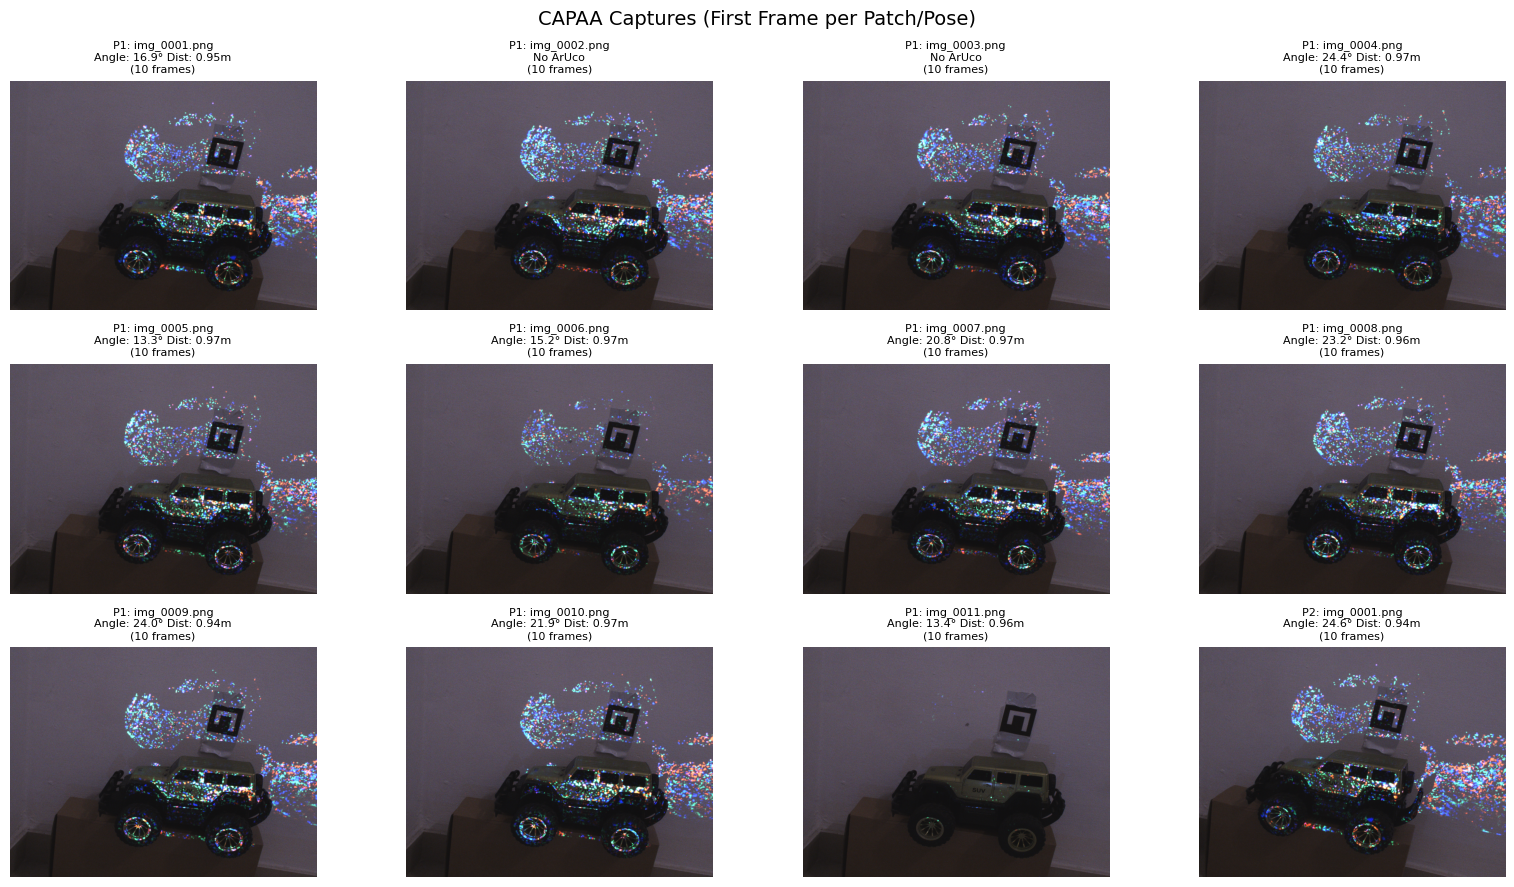

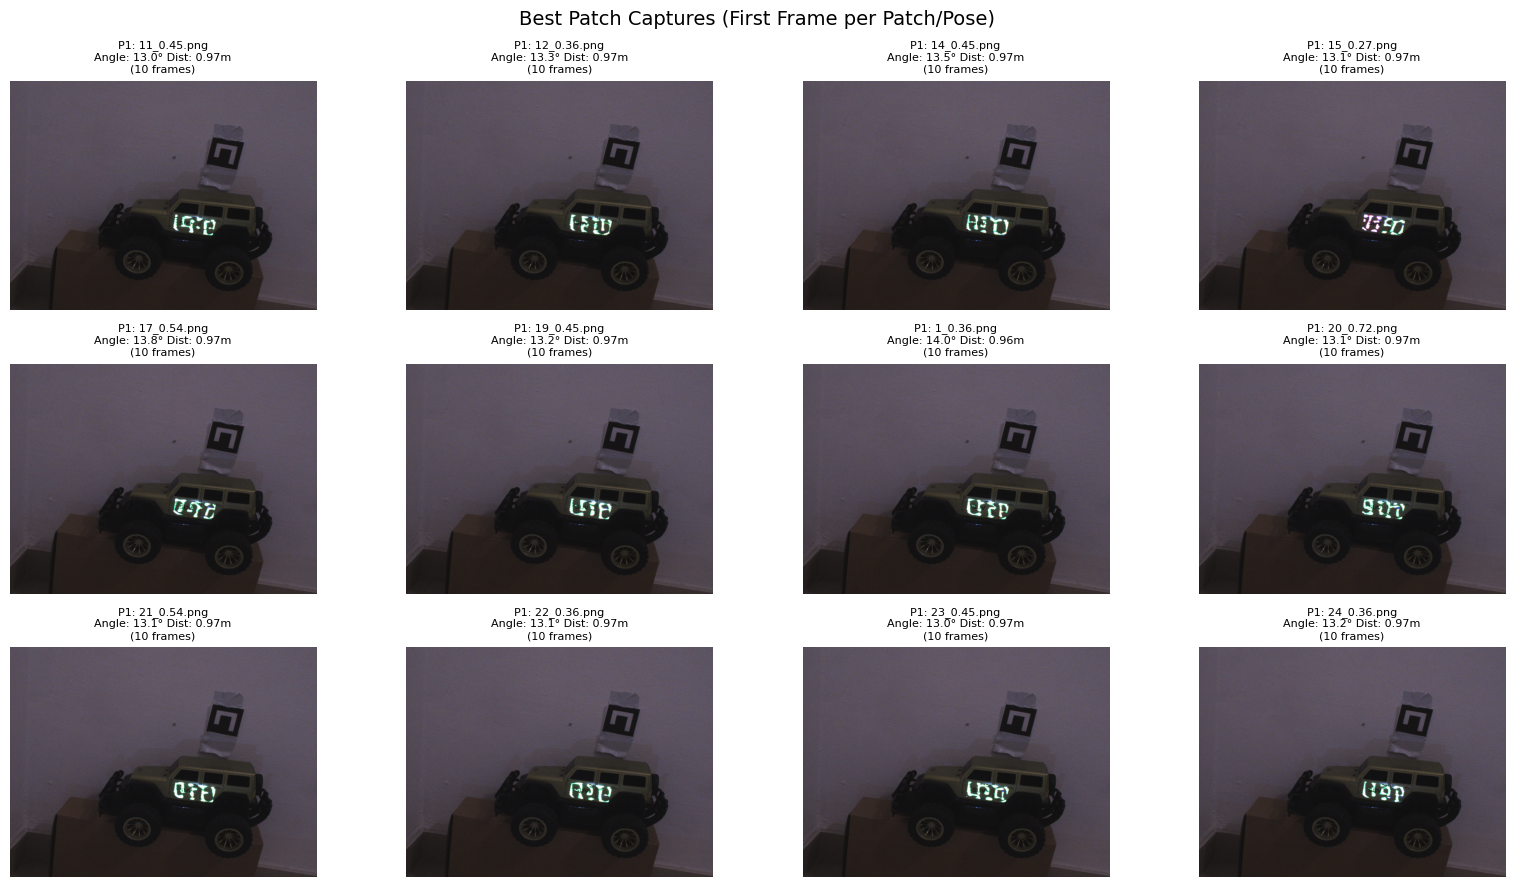

In [25]:
# Visualize captured frames grid (using matplotlib for image display)
# Shows first frame of each capture with metadata

def show_captures_grid(captures, title, max_cols=4, max_rows=3):
    """Show a grid of captured frames (first frame from each capture).
    In multi-pose mode, each capture is a (patch, pose) combination."""
    n = min(len(captures), max_cols * max_rows)
    if n == 0:
        print(f"No captures to display for {title}")
        return None
    
    cols = min(n, max_cols)
    rows = (n + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
    if rows == 1 and cols == 1:
        axes = [[axes]]
    elif rows == 1:
        axes = [axes]
    elif cols == 1:
        axes = [[ax] for ax in axes]
    
    is_multi_pose = 'pose_idx' in captures[0] if len(captures) > 0 else False
    
    for idx in range(n):
        row, col = idx // cols, idx % cols
        ax = axes[row][col]
        
        # Use first frame from the list of frames
        frame_rgb = cv2.cvtColor(captures[idx]['frames'][0], cv2.COLOR_BGR2RGB)
        ax.imshow(frame_rgb)
        
        patch_name = captures[idx]['patch_name'][:15] + '...' if len(captures[idx]['patch_name']) > 15 else captures[idx]['patch_name']
        angle = captures[idx]['angle']
        dist = captures[idx]['distance']
        num_frames = captures[idx]['num_frames']
        
        # Build title
        if is_multi_pose:
            pose_idx = captures[idx]['pose_idx']
            title_line1 = f"P{pose_idx+1}: {patch_name}"
        else:
            title_line1 = patch_name
        
        if angle is not None:
            title_line2 = f"Angle: {angle:.1f}° Dist: {dist:.2f}m"
        else:
            title_line2 = "No ArUco"
        
        title_line3 = f"({num_frames} frames)"
        
        ax.set_title(f"{title_line1}\n{title_line2}\n{title_line3}", fontsize=8)
        ax.axis('off')
    
    # Hide empty subplots
    for idx in range(n, rows * cols):
        row, col = idx // cols, idx % cols
        axes[row][col].axis('off')
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    return fig

# Check if multi-pose
capaa_multi_pose = 'pose_idx' in capaa_captures[0] if len(capaa_captures) > 0 else False
bp_multi_pose = 'pose_idx' in best_patch_captures[0] if len(best_patch_captures) > 0 else False

# Show CAPAA captures
capaa_title = "CAPAA Captures (First Frame per Patch/Pose)" if capaa_multi_pose else "CAPAA Captures (First Frame per Patch)"
fig1 = show_captures_grid(capaa_captures, capaa_title)
if fig1:
    plt.savefig('capaa_captures_grid.png', dpi=150, bbox_inches='tight')
plt.show()

# Show Best Patch captures
bp_title = "Best Patch Captures (First Frame per Patch/Pose)" if bp_multi_pose else "Best Patch Captures (First Frame per Patch)"
fig2 = show_captures_grid(best_patch_captures, bp_title)
if fig2:
    plt.savefig('best_patch_captures_grid.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Save all results
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H_%M")
output_dir = f"batch_capture_results_{timestamp}"
os.makedirs(output_dir, exist_ok=True)

# Save dataframes
capaa_df.to_csv(f"{output_dir}/capaa_results.csv", index=False)
bp_df.to_csv(f"{output_dir}/best_patch_results.csv", index=False)

# Save summaries
capaa_summary.to_csv(f"{output_dir}/capaa_summary.csv", index=False)
bp_summary.to_csv(f"{output_dir}/best_patch_summary.csv", index=False)

# Save captures
with open(f"{output_dir}/capaa_captures.pkl", "wb") as f:
    pickle.dump(capaa_captures, f)
with open(f"{output_dir}/best_patch_captures.pkl", "wb") as f:
    pickle.dump(best_patch_captures, f)

print(f"✓ Results saved to '{output_dir}/'")
print(f"  - capaa_results.csv")
print(f"  - best_patch_results.csv")
print(f"  - capaa_summary.csv")
print(f"  - best_patch_summary.csv")
print(f"  - capaa_captures.pkl")
print(f"  - best_patch_captures.pkl")

✓ Results saved to 'batch_capture_results_2025-12-25_17_00/'
  - capaa_results.csv
  - best_patch_results.csv
  - capaa_summary.csv
  - best_patch_summary.csv
  - capaa_captures.pkl
  - best_patch_captures.pkl


In [18]:
# Final summary
print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)

capaa_total_frames = sum(c['num_frames'] for c in capaa_captures)
bp_total_frames = sum(c['num_frames'] for c in best_patch_captures)

# Check multi-pose
capaa_multi_pose = 'pose_idx' in capaa_captures[0] if len(capaa_captures) > 0 else False
bp_multi_pose = 'pose_idx' in best_patch_captures[0] if len(best_patch_captures) > 0 else False

if capaa_multi_pose:
    num_patches = len(set(c['patch_idx'] for c in capaa_captures))
    num_poses = len(set(c['pose_idx'] for c in capaa_captures))
    print(f"\nCAPAA: {num_patches} patches × {num_poses} poses = {len(capaa_captures)} captures, {capaa_total_frames} total frames")
else:
    print(f"\nCAPAA: {len(capaa_captures)} patches, {capaa_total_frames} total frames")

if bp_multi_pose:
    num_patches = len(set(c['patch_idx'] for c in best_patch_captures))
    num_poses = len(set(c['pose_idx'] for c in best_patch_captures))
    print(f"Best Patch: {num_patches} patches × {num_poses} poses = {len(best_patch_captures)} captures, {bp_total_frames} total frames")
else:
    print(f"Best Patch: {len(best_patch_captures)} patches, {bp_total_frames} total frames")

print(f"\n--- Frame-Level Average Success Rates ---")
print(f"  CAPAA: {capaa_summary['Frame Success Rate'].mean():.1f}%")
print(f"  Best Patch: {bp_summary['Frame Success Rate'].mean():.1f}%")

print(f"\n--- Patch-Level Average Success Rates (Majority Vote) ---")
print(f"  CAPAA: {capaa_summary['Patch Success Rate'].mean():.1f}%")
print(f"  Best Patch: {bp_summary['Patch Success Rate'].mean():.1f}%")

# Winner per model (using patch-level majority vote)
print(f"\nWinner per Model (Patch-Level):")
for i in range(len(capaa_summary)):
    model = capaa_summary.iloc[i]['Model']
    c_rate = capaa_summary.iloc[i]['Patch Success Rate']
    b_rate = bp_summary.iloc[i]['Patch Success Rate']
    
    if c_rate > b_rate:
        winner = 'CAPAA'
    elif b_rate > c_rate:
        winner = 'Best Patch'
    else:
        winner = 'Tie'
    
    print(f"  {model}: {winner} (CAPAA: {c_rate:.1f}% vs BP: {b_rate:.1f}%)")


FINAL SUMMARY

CAPAA: 11 patches × 4 poses = 44 captures, 440 total frames
Best Patch: 17 patches × 4 poses = 68 captures, 680 total frames

--- Frame-Level Average Success Rates ---
  CAPAA: 41.6%
  Best Patch: 75.9%

--- Patch-Level Average Success Rates (Majority Vote) ---
  CAPAA: 29.5%
  Best Patch: 76.0%

Winner per Model (Patch-Level):
  v1_inception: Best Patch (CAPAA: 0.0% vs BP: 100.0%)
  v1_resnet: Best Patch (CAPAA: 54.5% vs BP: 100.0%)
  v1_vgg: Best Patch (CAPAA: 63.6% vs BP: 100.0%)
  v1_vit: Best Patch (CAPAA: 54.5% vs BP: 100.0%)
  v1_dino: Best Patch (CAPAA: 18.2% vs BP: 76.5%)
  v1_combined: Best Patch (CAPAA: 36.4% vs BP: 100.0%)
  v2_convnext: Best Patch (CAPAA: 90.9% vs BP: 100.0%)
  v2_efficientnet: CAPAA (CAPAA: 18.2% vs BP: 0.0%)
  v2_mobilenet: Best Patch (CAPAA: 0.0% vs BP: 100.0%)
  v2_swin: Tie (CAPAA: 0.0% vs BP: 0.0%)
  v2_combined: Best Patch (CAPAA: 0.0% vs BP: 58.8%)
  dino_standalone: Best Patch (CAPAA: 18.2% vs BP: 76.5%)


In [31]:
# =============================================================================
# EXPORT ALL RESULTS TO A SINGLE FOLDER FOR INVESTIGATION
# =============================================================================
import shutil
from pathlib import Path

# Create a timestamped results folder
export_timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H_%M_%S")
export_folder = Path(f"experiment_results_{export_timestamp}")
export_folder.mkdir(exist_ok=True)

# Create subfolders
(export_folder / "data").mkdir(exist_ok=True)
(export_folder / "plots").mkdir(exist_ok=True)
(export_folder / "captures").mkdir(exist_ok=True)

print(f"📁 Creating export folder: {export_folder}")
print("="*60)

# 1. Save DataFrames (CSV)
print("\n📊 Saving data files...")
capaa_df.to_csv(export_folder / "data" / "capaa_results.csv", index=False)
bp_df.to_csv(export_folder / "data" / "best_patch_results.csv", index=False)
capaa_summary.to_csv(export_folder / "data" / "capaa_summary.csv", index=False)
bp_summary.to_csv(export_folder / "data" / "best_patch_summary.csv", index=False)
print(f"  ✓ capaa_results.csv")
print(f"  ✓ best_patch_results.csv")
print(f"  ✓ capaa_summary.csv")
print(f"  ✓ best_patch_summary.csv")

# 2. Save captures (pickle)
print("\n📸 Saving capture data...")
with open(export_folder / "data" / "capaa_captures.pkl", "wb") as f:
    pickle.dump(capaa_captures, f)
with open(export_folder / "data" / "best_patch_captures.pkl", "wb") as f:
    pickle.dump(best_patch_captures, f)
print(f"  ✓ capaa_captures.pkl")
print(f"  ✓ best_patch_captures.pkl")

# 3. Copy Plotly HTML plots
print("\n📈 Copying interactive Plotly plots...")
plotly_files = [
    "batch_capture_comparison.html",
    "success_rate_vs_pose.html",
    "success_rate_vs_pose_bars.html",
    "success_rate_heatmap.html",
    "radar_by_angle_per_model.html",
    "angle_distance_scatter.html",
    "angle_distance_3d.html",
    "per_patch_success_rates.html"
]

for plot_file in plotly_files:
    src = Path(plot_file)
    if src.exists():
        shutil.copy(src, export_folder / "plots" / plot_file)
        print(f"  ✓ {plot_file}")
    else:
        print(f"  ⚠ {plot_file} not found (skipped)")

# 4. Save matplotlib figures as PNG
print("\n🖼️ Saving static image grid...")
try:
    # Re-create the image grid and save it
    n_show = min(len(capaa_captures), len(best_patch_captures), 6)
    if n_show > 0:
        fig_save, axes_save = plt.subplots(2, n_show, figsize=(20, 8))
        fig_save.suptitle('Sample Captures: CAPAA (top) vs Best Patch (bottom)', fontsize=14)
        
        for i in range(n_show):
            # Get first frame from frames list
            if len(capaa_captures) > i and 'frames' in capaa_captures[i] and len(capaa_captures[i]['frames']) > 0:
                frame = capaa_captures[i]['frames'][0]
                axes_save[0, i].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
                patch_label = capaa_patches[capaa_captures[i]['patch_idx']] if 'patch_idx' in capaa_captures[i] else f"Patch {i+1}"
                patch_label = os.path.basename(patch_label) if isinstance(patch_label, str) else patch_label
                axes_save[0, i].set_title(f"{patch_label[:20]}", fontsize=9)
            axes_save[0, i].axis('off')
            
            if len(best_patch_captures) > i and 'frames' in best_patch_captures[i] and len(best_patch_captures[i]['frames']) > 0:
                frame = best_patch_captures[i]['frames'][0]
                axes_save[1, i].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
                patch_label = best_patch_patches[best_patch_captures[i]['patch_idx']] if 'patch_idx' in best_patch_captures[i] else f"Patch {i+1}"
                patch_label = os.path.basename(patch_label) if isinstance(patch_label, str) else patch_label
                axes_save[1, i].set_title(f"{patch_label[:20]}", fontsize=9)
            axes_save[1, i].axis('off')
        
        plt.tight_layout()
        fig_save.savefig(export_folder / "plots" / "sample_captures_grid.png", dpi=150, bbox_inches='tight')
        plt.close(fig_save)
        print(f"  ✓ sample_captures_grid.png")
    else:
        print(f"  ⚠ No captures to save")
except Exception as e:
    print(f"  ⚠ Could not save image grid: {e}")

# 5. Save all captured frames as images
print("\n🖼️ Saving individual capture frames...")
capaa_captures_folder = export_folder / "captures" / "capaa"
bp_captures_folder = export_folder / "captures" / "best_patch"
capaa_captures_folder.mkdir(exist_ok=True)
bp_captures_folder.mkdir(exist_ok=True)

capaa_frames_saved = 0
for i, cap_data in enumerate(capaa_captures):
    patch_name = os.path.basename(capaa_patches[cap_data['patch_idx']]) if 'patch_idx' in cap_data else f"patch_{i}"
    patch_name = os.path.splitext(patch_name)[0]  # Remove extension
    pose_str = f"_pose{cap_data['pose_idx']}" if 'pose_idx' in cap_data else ""
    
    # Save first frame (or all frames if desired)
    if 'frames' in cap_data and len(cap_data['frames']) > 0:
        frame_path = capaa_captures_folder / f"{patch_name}{pose_str}.png"
        cv2.imwrite(str(frame_path), cap_data['frames'][0])
        capaa_frames_saved += 1
print(f"  ✓ {capaa_frames_saved} CAPAA frames saved")

bp_frames_saved = 0
for i, cap_data in enumerate(best_patch_captures):
    patch_name = os.path.basename(best_patch_patches[cap_data['patch_idx']]) if 'patch_idx' in cap_data else f"patch_{i}"
    patch_name = os.path.splitext(patch_name)[0]  # Remove extension
    pose_str = f"_pose{cap_data['pose_idx']}" if 'pose_idx' in cap_data else ""
    
    # Save first frame
    if 'frames' in cap_data and len(cap_data['frames']) > 0:
        frame_path = bp_captures_folder / f"{patch_name}{pose_str}.png"
        cv2.imwrite(str(frame_path), cap_data['frames'][0])
        bp_frames_saved += 1
print(f"  ✓ {bp_frames_saved} Best Patch frames saved")

# 6. Generate a summary report
print("\n📝 Generating summary report...")
report_lines = [
    f"# Experiment Results Summary",
    f"Generated: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
    "",
    "## Configuration",
    f"- Multi-pose mode: {MULTI_POSE}",
    f"- Number of captures per patch: {NUM_CAPTURES}",
    f"- Number of poses: {NUM_POSES if MULTI_POSE else 1}",
    f"- CAPAA folder: {capaa_folder}",
    f"- Best Patch folder: {best_patch_folder}",
    "",
    "## Results Overview",
    "",
    "### Frame-Level Success Rates",
    f"- CAPAA Average: {capaa_summary['Frame Success Rate'].mean():.1f}%",
    f"- Best Patch Average: {bp_summary['Frame Success Rate'].mean():.1f}%",
    "",
    "### Patch-Level Success Rates (Majority Vote)",
    f"- CAPAA Average: {capaa_summary['Patch Success Rate'].mean():.1f}%",
    f"- Best Patch Average: {bp_summary['Patch Success Rate'].mean():.1f}%",
    "",
    "### Model-by-Model Comparison",
]

for i in range(len(capaa_summary)):
    model = capaa_summary.iloc[i]['Model']
    c_rate = capaa_summary.iloc[i]['Patch Success Rate']
    b_rate = bp_summary.iloc[i]['Patch Success Rate']
    winner = 'CAPAA' if c_rate > b_rate else ('Best Patch' if b_rate > c_rate else 'Tie')
    report_lines.append(f"- **{model}**: {winner} (CAPAA: {c_rate:.1f}% vs BP: {b_rate:.1f}%)")

report_lines.extend([
    "",
    "## Files in this Export",
    "",
    "### Data Files (data/)",
    "- `capaa_results.csv` - Per-frame classification results for CAPAA",
    "- `best_patch_results.csv` - Per-frame classification results for Best Patch",
    "- `capaa_summary.csv` - Aggregated metrics per model for CAPAA",
    "- `best_patch_summary.csv` - Aggregated metrics per model for Best Patch",
    "- `capaa_captures.pkl` - Raw capture data (frames + metadata)",
    "- `best_patch_captures.pkl` - Raw capture data (frames + metadata)",
    "",
    "### Plots (plots/)",
    "- `batch_capture_comparison.html` - Main comparison chart",
    "- `success_rate_vs_pose.html` - Success rate by pose (line chart)",
    "- `success_rate_vs_pose_bars.html` - Success rate by pose (bar chart)",
    "- `success_rate_heatmap.html` - Heatmap of success rates",
    "- `radar_by_angle_per_model.html` - Radar charts by capture angle",
    "- `angle_distance_scatter.html` - Angle vs success scatter plot",
    "- `angle_distance_3d.html` - 3D angle-distance-success visualization",
    "- `per_patch_success_rates.html` - Per-patch success rates",
    "- `sample_captures_grid.png` - Sample capture images",
    "",
    "### Captures (captures/)",
    "- `capaa/` - Individual CAPAA capture frames",
    "- `best_patch/` - Individual Best Patch capture frames",
])

with open(export_folder / "README.md", "w") as f:
    f.write("\n".join(report_lines))
print(f"  ✓ README.md")

# Final summary
print("\n" + "="*60)
print(f"✅ EXPORT COMPLETE: {export_folder}")
print("="*60)
print(f"\n📁 Folder structure:")
print(f"   {export_folder}/")
print(f"   ├── README.md")
print(f"   ├── data/")
print(f"   │   ├── capaa_results.csv")
print(f"   │   ├── best_patch_results.csv")
print(f"   │   ├── capaa_summary.csv")
print(f"   │   ├── best_patch_summary.csv")
print(f"   │   ├── capaa_captures.pkl")
print(f"   │   └── best_patch_captures.pkl")
print(f"   ├── plots/")
print(f"   │   ├── *.html (interactive Plotly charts)")
print(f"   │   └── sample_captures_grid.png")
print(f"   └── captures/")
print(f"       ├── capaa/ ({capaa_frames_saved} frames)")
print(f"       └── best_patch/ ({bp_frames_saved} frames)")

📁 Creating export folder: experiment_results_2025-12-25_17_41_43

📊 Saving data files...
  ✓ capaa_results.csv
  ✓ best_patch_results.csv
  ✓ capaa_summary.csv
  ✓ best_patch_summary.csv

📸 Saving capture data...
  ✓ capaa_captures.pkl
  ✓ best_patch_captures.pkl

📈 Copying interactive Plotly plots...
  ✓ batch_capture_comparison.html
  ✓ success_rate_vs_pose.html
  ✓ success_rate_vs_pose_bars.html
  ✓ success_rate_heatmap.html
  ✓ radar_by_angle_per_model.html
  ✓ angle_distance_scatter.html
  ✓ angle_distance_3d.html
  ✓ per_patch_success_rates.html

🖼️ Saving static image grid...
  ✓ sample_captures_grid.png

🖼️ Saving individual capture frames...
  ✓ 44 CAPAA frames saved
  ✓ 68 Best Patch frames saved

📝 Generating summary report...
  ✓ README.md

✅ EXPORT COMPLETE: experiment_results_2025-12-25_17_41_43

📁 Folder structure:
   experiment_results_2025-12-25_17_41_43/
   ├── README.md
   ├── data/
   │   ├── capaa_results.csv
   │   ├── best_patch_results.csv
   │   ├── capaa_summa

## 📊 Model-Category Tables: V1 (Seen), V2 (Unseen), DINO (Unseen-Strong)

In [39]:
# =============================================================================
# TABLE V1: V1 Models (SEEN During Training)
# These are the models that our adversarial patches were trained on
# =============================================================================

import pandas as pd

# Define V1 models (seen during training) - Note: DINO is NOT part of V1 training
v1_models = ['v1_inception', 'v1_resnet', 'v1_vgg', 'v1_vit', 'v1_combined']
v1_model_display = {
    'v1_inception': 'Inception V3',
    'v1_resnet': 'ResNet18',
    'v1_vgg': 'VGG16',
    'v1_vit': 'ViT-B/16',
    'v1_combined': 'V1 Ensemble (Joint)'
}

print("="*100)
print("TABLE V1: Attack Success on SEEN Models (V1 - Used During Training)")
print("="*100)
print("These models were part of the training ensemble for our adversarial patches.\n")

# Build table data
v1_table_data = []

for model in v1_models:
    model_display = v1_model_display.get(model, model)
    
    # Get CAPAA results
    capaa_row = capaa_summary[capaa_summary['Model'] == model]
    capaa_frame = capaa_row['Frame Success Rate'].values[0] if len(capaa_row) > 0 else 0
    capaa_patch = capaa_row['Patch Success Rate'].values[0] if len(capaa_row) > 0 else 0
    
    # Get Best Patch results
    bp_row = bp_summary[bp_summary['Model'] == model]
    bp_frame = bp_row['Frame Success Rate'].values[0] if len(bp_row) > 0 else 0
    bp_patch = bp_row['Patch Success Rate'].values[0] if len(bp_row) > 0 else 0
    
    # Calculate improvement
    frame_diff = capaa_frame - bp_frame
    patch_diff = capaa_patch - bp_patch
    
    v1_table_data.append({
        'Classifier': model_display,
        'CAPAA Frame (%)': f"{capaa_frame:.1f}",
        'BP Frame (%)': f"{bp_frame:.1f}",
        'Δ Frame': f"{'+' if frame_diff >= 0 else ''}{frame_diff:.1f}",
        'CAPAA Patch (%)': f"{capaa_patch:.1f}",
        'BP Patch (%)': f"{bp_patch:.1f}",
        'Δ Patch': f"{'+' if patch_diff >= 0 else ''}{patch_diff:.1f}"
    })

# Add average row for V1
avg_capaa_frame_v1 = capaa_summary[capaa_summary['Model'].isin(v1_models)]['Frame Success Rate'].mean()
avg_bp_frame_v1 = bp_summary[bp_summary['Model'].isin(v1_models)]['Frame Success Rate'].mean()
avg_capaa_patch_v1 = capaa_summary[capaa_summary['Model'].isin(v1_models)]['Patch Success Rate'].mean()
avg_bp_patch_v1 = bp_summary[bp_summary['Model'].isin(v1_models)]['Patch Success Rate'].mean()

v1_table_data.append({
    'Classifier': '**Average (V1)**',
    'CAPAA Frame (%)': f"{avg_capaa_frame_v1:.1f}",
    'BP Frame (%)': f"{avg_bp_frame_v1:.1f}",
    'Δ Frame': f"{'+' if (avg_capaa_frame_v1 - avg_bp_frame_v1) >= 0 else ''}{avg_capaa_frame_v1 - avg_bp_frame_v1:.1f}",
    'CAPAA Patch (%)': f"{avg_capaa_patch_v1:.1f}",
    'BP Patch (%)': f"{avg_bp_patch_v1:.1f}",
    'Δ Patch': f"{'+' if (avg_capaa_patch_v1 - avg_bp_patch_v1) >= 0 else ''}{avg_capaa_patch_v1 - avg_bp_patch_v1:.1f}"
})

v1_table_df = pd.DataFrame(v1_table_data)

# Display with styling
print("\n📊 Table V1: Attack Success Rates on SEEN Models (V1)")
print("-"*100)
print(v1_table_df.to_string(index=False))

# Generate LaTeX
latex_v1 = r"""
\begin{table}[t]
\centering
\caption{Attack Success Rates on V1 Models (SEEN During Training)}
\label{tab:v1_seen_models}
\begin{tabular}{l|cc|c|cc|c}
\toprule
\textbf{Classifier} & \multicolumn{3}{c|}{\textbf{Frame Success (\%)}} & \multicolumn{3}{c}{\textbf{Patch Success (\%)}} \\
& CAPAA & BP & $\Delta$ & CAPAA & BP & $\Delta$ \\
\midrule
"""

for row in v1_table_data[:-1]:  # Exclude average row first
    classifier = row['Classifier'].replace('_', '\\_')
    latex_v1 += f"{classifier} & {row['CAPAA Frame (%)']} & {row['BP Frame (%)']} & {row['Δ Frame']} & {row['CAPAA Patch (%)']} & {row['BP Patch (%)']} & {row['Δ Patch']} \\\\\n"

# Add average with bold
avg_row = v1_table_data[-1]
latex_v1 += r"\midrule" + "\n"
latex_v1 += f"\\textbf{{Average (V1)}} & \\textbf{{{avg_row['CAPAA Frame (%)']:.0s}}} & \\textbf{{{avg_row['BP Frame (%)']:.0s}}} & \\textbf{{{avg_row['Δ Frame']}}} & \\textbf{{{avg_row['CAPAA Patch (%)']:.0s}}} & \\textbf{{{avg_row['BP Patch (%)']:.0s}}} & \\textbf{{{avg_row['Δ Patch']}}} \\\\\n"

latex_v1 += r"""
\bottomrule
\end{tabular}
\end{table}
"""

print("\n\n📝 LaTeX Code for Table V1:")
print("-"*60)
print(latex_v1)

TABLE V1: Attack Success on SEEN Models (V1 - Used During Training)
These models were part of the training ensemble for our adversarial patches.


📊 Table V1: Attack Success Rates on SEEN Models (V1)
----------------------------------------------------------------------------------------------------
         Classifier CAPAA Frame (%) BP Frame (%) Δ Frame CAPAA Patch (%) BP Patch (%) Δ Patch
       Inception V3            16.1        100.0   -83.9             0.0        100.0  -100.0
           ResNet18            54.1        100.0   -45.9            54.5        100.0   -45.5
              VGG16            62.5         97.5   -35.0            63.6        100.0   -36.4
           ViT-B/16            55.7         82.2   -26.5            54.5        100.0   -45.5
V1 Ensemble (Joint)            39.5        100.0   -60.5            36.4        100.0   -63.6
   **Average (V1)**            45.6         95.9   -50.4            41.8        100.0   -58.2


📝 LaTeX Code for Table V1:
------------

In [36]:
# =============================================================================
# TABLE V2: V2 Models (UNSEEN During Training)
# These models were NOT part of the training process - tests transferability
# =============================================================================

# Define V2 models (unseen during training)
v2_models = ['v2_convnext', 'v2_efficientnet', 'v2_mobilenet', 'v2_swin', 'v2_combined']
v2_model_display = {
    'v2_convnext': 'ConvNeXt Base',
    'v2_efficientnet': 'EfficientNet B0',
    'v2_mobilenet': 'MobileNetV3 Large',
    'v2_swin': 'Swin Transformer',
    'v2_combined': 'V2 Ensemble (Joint)'
}

print("="*100)
print("TABLE V2: Attack Success on UNSEEN Models (V2 - NOT Used During Training)")
print("="*100)
print("These models test transferability - they were NOT part of the training ensemble.\n")

# Build table data
v2_table_data = []

for model in v2_models:
    model_display = v2_model_display.get(model, model)
    
    # Get CAPAA results
    capaa_row = capaa_summary[capaa_summary['Model'] == model]
    capaa_frame = capaa_row['Frame Success Rate'].values[0] if len(capaa_row) > 0 else 0
    capaa_patch = capaa_row['Patch Success Rate'].values[0] if len(capaa_row) > 0 else 0
    
    # Get Best Patch results
    bp_row = bp_summary[bp_summary['Model'] == model]
    bp_frame = bp_row['Frame Success Rate'].values[0] if len(bp_row) > 0 else 0
    bp_patch = bp_row['Patch Success Rate'].values[0] if len(bp_row) > 0 else 0
    
    # Calculate improvement
    frame_diff = capaa_frame - bp_frame
    patch_diff = capaa_patch - bp_patch
    
    v2_table_data.append({
        'Classifier': model_display,
        'CAPAA Frame (%)': f"{capaa_frame:.1f}",
        'BP Frame (%)': f"{bp_frame:.1f}",
        'Δ Frame': f"{'+' if frame_diff >= 0 else ''}{frame_diff:.1f}",
        'CAPAA Patch (%)': f"{capaa_patch:.1f}",
        'BP Patch (%)': f"{bp_patch:.1f}",
        'Δ Patch': f"{'+' if patch_diff >= 0 else ''}{patch_diff:.1f}"
    })

# Add average row for V2
avg_capaa_frame_v2 = capaa_summary[capaa_summary['Model'].isin(v2_models)]['Frame Success Rate'].mean()
avg_bp_frame_v2 = bp_summary[bp_summary['Model'].isin(v2_models)]['Frame Success Rate'].mean()
avg_capaa_patch_v2 = capaa_summary[capaa_summary['Model'].isin(v2_models)]['Patch Success Rate'].mean()
avg_bp_patch_v2 = bp_summary[bp_summary['Model'].isin(v2_models)]['Patch Success Rate'].mean()

v2_table_data.append({
    'Classifier': '**Average (V2)**',
    'CAPAA Frame (%)': f"{avg_capaa_frame_v2:.1f}",
    'BP Frame (%)': f"{avg_bp_frame_v2:.1f}",
    'Δ Frame': f"{'+' if (avg_capaa_frame_v2 - avg_bp_frame_v2) >= 0 else ''}{avg_capaa_frame_v2 - avg_bp_frame_v2:.1f}",
    'CAPAA Patch (%)': f"{avg_capaa_patch_v2:.1f}",
    'BP Patch (%)': f"{avg_bp_patch_v2:.1f}",
    'Δ Patch': f"{'+' if (avg_capaa_patch_v2 - avg_bp_patch_v2) >= 0 else ''}{avg_capaa_patch_v2 - avg_bp_patch_v2:.1f}"
})

v2_table_df = pd.DataFrame(v2_table_data)

# Display with styling
print("\n📊 Table V2: Attack Success Rates on UNSEEN Models (V2)")
print("-"*100)
print(v2_table_df.to_string(index=False))

# Generate LaTeX
latex_v2 = r"""
\begin{table}[t]
\centering
\caption{Attack Success Rates on V2 Models (UNSEEN - Tests Transferability)}
\label{tab:v2_unseen_models}
\begin{tabular}{l|cc|c|cc|c}
\toprule
\textbf{Classifier} & \multicolumn{3}{c|}{\textbf{Frame Success (\%)}} & \multicolumn{3}{c}{\textbf{Patch Success (\%)}} \\
& CAPAA & BP & $\Delta$ & CAPAA & BP & $\Delta$ \\
\midrule
"""

for row in v2_table_data[:-1]:  # Exclude average row first
    classifier = row['Classifier'].replace('_', '\\_')
    latex_v2 += f"{classifier} & {row['CAPAA Frame (%)']} & {row['BP Frame (%)']} & {row['Δ Frame']} & {row['CAPAA Patch (%)']} & {row['BP Patch (%)']} & {row['Δ Patch']} \\\\\n"

# Add average with bold
avg_row_v2 = v2_table_data[-1]
latex_v2 += r"\midrule" + "\n"
latex_v2 += f"\\textbf{{Average (V2)}} & \\textbf{{{avg_row_v2['CAPAA Frame (%)']:.0s}}} & \\textbf{{{avg_row_v2['BP Frame (%)']:.0s}}} & \\textbf{{{avg_row_v2['Δ Frame']}}} & \\textbf{{{avg_row_v2['CAPAA Patch (%)']:.0s}}} & \\textbf{{{avg_row_v2['BP Patch (%)']:.0s}}} & \\textbf{{{avg_row_v2['Δ Patch']}}} \\\\\n"

latex_v2 += r"""
\bottomrule
\end{tabular}
\end{table}
"""

print("\n\n📝 LaTeX Code for Table V2:")
print("-"*60)
print(latex_v2)

TABLE V2: Attack Success on UNSEEN Models (V2 - NOT Used During Training)
These models test transferability - they were NOT part of the training ensemble.


📊 Table V2: Attack Success Rates on UNSEEN Models (V2)
----------------------------------------------------------------------------------------------------
         Classifier CAPAA Frame (%) BP Frame (%) Δ Frame CAPAA Patch (%) BP Patch (%) Δ Patch
      ConvNeXt Base            90.7        100.0    -9.3            90.9        100.0    -9.1
    EfficientNet B0            33.4         25.0    +8.4            18.2          0.0   +18.2
  MobileNetV3 Large            26.1        100.0   -73.9             0.0        100.0  -100.0
   Swin Transformer            22.5         21.9    +0.6             0.0          0.0    +0.0
V2 Ensemble (Joint)            30.5         58.2   -27.8             0.0         58.8   -58.8
   **Average (V2)**            40.6         61.0   -20.4            21.8         51.8   -29.9


📝 LaTeX Code for Table V2:


In [37]:
# =============================================================================
# TABLE DINO: DINOv2 Standalone (UNSEEN, Strong Model)
# DINOv2 is a particularly challenging model - strong feature extraction
# =============================================================================

# DINO standalone model
dino_model = ['dino_standalone']
dino_model_display = {'dino_standalone': 'DINOv2 (EfficientNet-B4 Head)'}

print("="*100)
print("TABLE DINO: Attack Success on DINOv2 Standalone (UNSEEN - Strong Model)")
print("="*100)
print("DINOv2 uses powerful self-supervised features - a challenging adversarial target.\n")

# Get DINO results
capaa_row = capaa_summary[capaa_summary['Model'] == 'dino_standalone']
bp_row = bp_summary[bp_summary['Model'] == 'dino_standalone']

capaa_frame_dino = capaa_row['Frame Success Rate'].values[0] if len(capaa_row) > 0 else 0
capaa_patch_dino = capaa_row['Patch Success Rate'].values[0] if len(capaa_row) > 0 else 0
bp_frame_dino = bp_row['Frame Success Rate'].values[0] if len(bp_row) > 0 else 0
bp_patch_dino = bp_row['Patch Success Rate'].values[0] if len(bp_row) > 0 else 0

frame_diff_dino = capaa_frame_dino - bp_frame_dino
patch_diff_dino = capaa_patch_dino - bp_patch_dino

# Create comprehensive DINO table
dino_table_data = [
    {
        'Metric': 'Frame-Level Success Rate',
        'CAPAA': f"{capaa_frame_dino:.1f}%",
        'Best Patch': f"{bp_frame_dino:.1f}%",
        'Difference (Δ)': f"{'+' if frame_diff_dino >= 0 else ''}{frame_diff_dino:.1f}%",
        'Winner': 'CAPAA' if capaa_frame_dino > bp_frame_dino else ('Best Patch' if bp_frame_dino > capaa_frame_dino else 'Tie')
    },
    {
        'Metric': 'Patch-Level Success Rate',
        'CAPAA': f"{capaa_patch_dino:.1f}%",
        'Best Patch': f"{bp_patch_dino:.1f}%",
        'Difference (Δ)': f"{'+' if patch_diff_dino >= 0 else ''}{patch_diff_dino:.1f}%",
        'Winner': 'CAPAA' if capaa_patch_dino > bp_patch_dino else ('Best Patch' if bp_patch_dino > capaa_patch_dino else 'Tie')
    }
]

# Add raw counts
capaa_frame_count = int(capaa_row['Frame Successful'].values[0]) if len(capaa_row) > 0 else 0
capaa_total_frames = int(capaa_row['Total Frames'].values[0]) if len(capaa_row) > 0 else 0
bp_frame_count = int(bp_row['Frame Successful'].values[0]) if len(bp_row) > 0 else 0
bp_total_frames = int(bp_row['Total Frames'].values[0]) if len(bp_row) > 0 else 0

capaa_patch_count = int(capaa_row['Patch Successful'].values[0]) if len(capaa_row) > 0 else 0
capaa_total_patches = int(capaa_row['Total Patches'].values[0]) if len(capaa_row) > 0 else 0
bp_patch_count = int(bp_row['Patch Successful'].values[0]) if len(bp_row) > 0 else 0
bp_total_patches = int(bp_row['Total Patches'].values[0]) if len(bp_row) > 0 else 0

dino_table_data.append({
    'Metric': 'Successful Frames',
    'CAPAA': f"{capaa_frame_count}/{capaa_total_frames}",
    'Best Patch': f"{bp_frame_count}/{bp_total_frames}",
    'Difference (Δ)': f"{capaa_frame_count - bp_frame_count:+d}",
    'Winner': '-'
})

dino_table_data.append({
    'Metric': 'Successful Patches (>50% frames)',
    'CAPAA': f"{capaa_patch_count}/{capaa_total_patches}",
    'Best Patch': f"{bp_patch_count}/{bp_total_patches}",
    'Difference (Δ)': f"{capaa_patch_count - bp_patch_count:+d}",
    'Winner': '-'
})

dino_table_df = pd.DataFrame(dino_table_data)

print("\n📊 Table DINO: Attack Success on DINOv2 Standalone")
print("-"*100)
print(dino_table_df.to_string(index=False))

# Summary analysis
print("\n\n📋 DINO Analysis Summary:")
print("-"*60)
winner_frame = 'CAPAA' if capaa_frame_dino > bp_frame_dino else ('Best Patch' if bp_frame_dino > capaa_frame_dino else 'Tie')
winner_patch = 'CAPAA' if capaa_patch_dino > bp_patch_dino else ('Best Patch' if bp_patch_dino > capaa_patch_dino else 'Tie')

print(f"• Frame-level winner: {winner_frame} ({'+' if frame_diff_dino >= 0 else ''}{frame_diff_dino:.1f}% difference)")
print(f"• Patch-level winner: {winner_patch} ({'+' if patch_diff_dino >= 0 else ''}{patch_diff_dino:.1f}% difference)")
print(f"• CAPAA achieved {capaa_frame_dino:.1f}% frame success vs {bp_frame_dino:.1f}% for Best Patch")

# Generate LaTeX
latex_dino = r"""
\begin{table}[t]
\centering
\caption{Attack Success on DINOv2 Standalone (Unseen, Strong Model)}
\label{tab:dino_standalone}
\begin{tabular}{l|cc|c}
\toprule
\textbf{Metric} & \textbf{CAPAA} & \textbf{Best Patch} & \textbf{$\Delta$} \\
\midrule
"""
latex_dino += f"Frame-Level Success (\\%) & {capaa_frame_dino:.1f} & {bp_frame_dino:.1f} & {'+' if frame_diff_dino >= 0 else ''}{frame_diff_dino:.1f} \\\\\n"
latex_dino += f"Patch-Level Success (\\%) & {capaa_patch_dino:.1f} & {bp_patch_dino:.1f} & {'+' if patch_diff_dino >= 0 else ''}{patch_diff_dino:.1f} \\\\\n"
latex_dino += r"\midrule" + "\n"
latex_dino += f"Successful Frames & {capaa_frame_count}/{capaa_total_frames} & {bp_frame_count}/{bp_total_frames} & {capaa_frame_count - bp_frame_count:+d} \\\\\n"
latex_dino += f"Successful Patches & {capaa_patch_count}/{capaa_total_patches} & {bp_patch_count}/{bp_total_patches} & {capaa_patch_count - bp_patch_count:+d} \\\\\n"
latex_dino += r"""
\bottomrule
\end{tabular}
\end{table}
"""

print("\n\n📝 LaTeX Code for Table DINO:")
print("-"*60)
print(latex_dino)

TABLE DINO: Attack Success on DINOv2 Standalone (UNSEEN - Strong Model)
DINOv2 uses powerful self-supervised features - a challenging adversarial target.


📊 Table DINO: Attack Success on DINOv2 Standalone
----------------------------------------------------------------------------------------------------
                          Metric   CAPAA Best Patch Difference (Δ)     Winner
        Frame-Level Success Rate   33.9%      63.1%         -29.2% Best Patch
        Patch-Level Success Rate   18.2%      76.5%         -58.3% Best Patch
               Successful Frames 149/440    429/680           -280          -
Successful Patches (>50% frames)    2/11      13/17            -11          -


📋 DINO Analysis Summary:
------------------------------------------------------------
• Frame-level winner: Best Patch (-29.2% difference)
• Patch-level winner: Best Patch (-58.3% difference)
• CAPAA achieved 33.9% frame success vs 63.1% for Best Patch


📝 LaTeX Code for Table DINO:
-----------------

In [40]:
# =============================================================================
# COMBINED SUMMARY TABLE: All Categories Side-by-Side
# =============================================================================

print("="*100)
print("COMBINED SUMMARY: V1 (Seen) vs V2 (Unseen) vs DINO (Unseen-Strong)")
print("="*100)

# Create summary comparison
summary_comparison = []

# V1 Average
summary_comparison.append({
    'Category': 'V1 Models (Seen)',
    'Models': 'Inception, ResNet, VGG, ViT',
    'CAPAA Frame (%)': f"{avg_capaa_frame_v1:.1f}",
    'BP Frame (%)': f"{avg_bp_frame_v1:.1f}",
    'Δ Frame': f"{'+' if (avg_capaa_frame_v1 - avg_bp_frame_v1) >= 0 else ''}{avg_capaa_frame_v1 - avg_bp_frame_v1:.1f}",
    'CAPAA Patch (%)': f"{avg_capaa_patch_v1:.1f}",
    'BP Patch (%)': f"{avg_bp_patch_v1:.1f}",
    'Δ Patch': f"{'+' if (avg_capaa_patch_v1 - avg_bp_patch_v1) >= 0 else ''}{avg_capaa_patch_v1 - avg_bp_patch_v1:.1f}"
})

# V2 Average
summary_comparison.append({
    'Category': 'V2 Models (Unseen)',
    'Models': 'ConvNeXt, EfficientNet, MobileNet, Swin',
    'CAPAA Frame (%)': f"{avg_capaa_frame_v2:.1f}",
    'BP Frame (%)': f"{avg_bp_frame_v2:.1f}",
    'Δ Frame': f"{'+' if (avg_capaa_frame_v2 - avg_bp_frame_v2) >= 0 else ''}{avg_capaa_frame_v2 - avg_bp_frame_v2:.1f}",
    'CAPAA Patch (%)': f"{avg_capaa_patch_v2:.1f}",
    'BP Patch (%)': f"{avg_bp_patch_v2:.1f}",
    'Δ Patch': f"{'+' if (avg_capaa_patch_v2 - avg_bp_patch_v2) >= 0 else ''}{avg_capaa_patch_v2 - avg_bp_patch_v2:.1f}"
})

# DINO Standalone
summary_comparison.append({
    'Category': 'DINO (Unseen-Strong)',
    'Models': 'DINOv2 + EfficientNet-B4',
    'CAPAA Frame (%)': f"{capaa_frame_dino:.1f}",
    'BP Frame (%)': f"{bp_frame_dino:.1f}",
    'Δ Frame': f"{'+' if frame_diff_dino >= 0 else ''}{frame_diff_dino:.1f}",
    'CAPAA Patch (%)': f"{capaa_patch_dino:.1f}",
    'BP Patch (%)': f"{bp_patch_dino:.1f}",
    'Δ Patch': f"{'+' if patch_diff_dino >= 0 else ''}{patch_diff_dino:.1f}"
})

# Overall average across all models
all_capaa_frame = capaa_summary['Frame Success Rate'].mean()
all_bp_frame = bp_summary['Frame Success Rate'].mean()
all_capaa_patch = capaa_summary['Patch Success Rate'].mean()
all_bp_patch = bp_summary['Patch Success Rate'].mean()

summary_comparison.append({
    'Category': '**Overall Average**',
    'Models': 'All 12 Models',
    'CAPAA Frame (%)': f"{all_capaa_frame:.1f}",
    'BP Frame (%)': f"{all_bp_frame:.1f}",
    'Δ Frame': f"{'+' if (all_capaa_frame - all_bp_frame) >= 0 else ''}{all_capaa_frame - all_bp_frame:.1f}",
    'CAPAA Patch (%)': f"{all_capaa_patch:.1f}",
    'BP Patch (%)': f"{all_bp_patch:.1f}",
    'Δ Patch': f"{'+' if (all_capaa_patch - all_bp_patch) >= 0 else ''}{all_capaa_patch - all_bp_patch:.1f}"
})

summary_df = pd.DataFrame(summary_comparison)

print("\n📊 Summary: Attack Success by Model Category")
print("-"*120)
print(summary_df.to_string(index=False))

# Key insights
print("\n\n📋 KEY INSIGHTS:")
print("="*80)

# Determine winners
v1_winner = 'CAPAA' if avg_capaa_frame_v1 > avg_bp_frame_v1 else 'Best Patch'
v2_winner = 'CAPAA' if avg_capaa_frame_v2 > avg_bp_frame_v2 else 'Best Patch'
dino_winner = 'CAPAA' if capaa_frame_dino > bp_frame_dino else 'Best Patch'
overall_winner = 'CAPAA' if all_capaa_frame > all_bp_frame else 'Best Patch'

print(f"• V1 (Seen Models):     {v1_winner} wins ({avg_capaa_frame_v1:.1f}% vs {avg_bp_frame_v1:.1f}%)")
print(f"• V2 (Unseen Models):   {v2_winner} wins ({avg_capaa_frame_v2:.1f}% vs {avg_bp_frame_v2:.1f}%)")
print(f"• DINO (Strong Model):  {dino_winner} wins ({capaa_frame_dino:.1f}% vs {bp_frame_dino:.1f}%)")
print(f"• Overall:              {overall_winner} wins ({all_capaa_frame:.1f}% vs {all_bp_frame:.1f}%)")

# Transferability analysis
print(f"\n• Transferability Gap (V1→V2): CAPAA {avg_capaa_frame_v1 - avg_capaa_frame_v2:+.1f}%, BP {avg_bp_frame_v1 - avg_bp_frame_v2:+.1f}%")
print(f"  → {'CAPAA' if abs(avg_capaa_frame_v1 - avg_capaa_frame_v2) < abs(avg_bp_frame_v1 - avg_bp_frame_v2) else 'Best Patch'} shows better transferability")

# Generate comprehensive LaTeX
latex_summary = r"""
\begin{table}[t]
\centering
\caption{Attack Success Rate Summary by Model Category}
\label{tab:summary_by_category}
\begin{tabular}{l|cc|c|cc|c}
\toprule
\textbf{Category} & \multicolumn{3}{c|}{\textbf{Frame Success (\%)}} & \multicolumn{3}{c}{\textbf{Patch Success (\%)}} \\
& CAPAA & BP & $\Delta$ & CAPAA & BP & $\Delta$ \\
\midrule
"""
latex_summary += f"V1 (Seen) & {avg_capaa_frame_v1:.1f} & {avg_bp_frame_v1:.1f} & {'+' if (avg_capaa_frame_v1 - avg_bp_frame_v1) >= 0 else ''}{avg_capaa_frame_v1 - avg_bp_frame_v1:.1f} & {avg_capaa_patch_v1:.1f} & {avg_bp_patch_v1:.1f} & {'+' if (avg_capaa_patch_v1 - avg_bp_patch_v1) >= 0 else ''}{avg_capaa_patch_v1 - avg_bp_patch_v1:.1f} \\\\\n"
latex_summary += f"V2 (Unseen) & {avg_capaa_frame_v2:.1f} & {avg_bp_frame_v2:.1f} & {'+' if (avg_capaa_frame_v2 - avg_bp_frame_v2) >= 0 else ''}{avg_capaa_frame_v2 - avg_bp_frame_v2:.1f} & {avg_capaa_patch_v2:.1f} & {avg_bp_patch_v2:.1f} & {'+' if (avg_capaa_patch_v2 - avg_bp_patch_v2) >= 0 else ''}{avg_capaa_patch_v2 - avg_bp_patch_v2:.1f} \\\\\n"
latex_summary += f"DINO (Unseen-Strong) & {capaa_frame_dino:.1f} & {bp_frame_dino:.1f} & {'+' if frame_diff_dino >= 0 else ''}{frame_diff_dino:.1f} & {capaa_patch_dino:.1f} & {bp_patch_dino:.1f} & {'+' if patch_diff_dino >= 0 else ''}{patch_diff_dino:.1f} \\\\\n"
latex_summary += r"\midrule" + "\n"
latex_summary += f"\\textbf{{Overall}} & \\textbf{{{all_capaa_frame:.1f}}} & \\textbf{{{all_bp_frame:.1f}}} & \\textbf{{{'+' if (all_capaa_frame - all_bp_frame) >= 0 else ''}{all_capaa_frame - all_bp_frame:.1f}}} & \\textbf{{{all_capaa_patch:.1f}}} & \\textbf{{{all_bp_patch:.1f}}} & \\textbf{{{'+' if (all_capaa_patch - all_bp_patch) >= 0 else ''}{all_capaa_patch - all_bp_patch:.1f}}} \\\\\n"
latex_summary += r"""
\bottomrule
\end{tabular}
\end{table}
"""

print("\n\n📝 LaTeX Code for Summary Table:")
print("-"*60)
print(latex_summary)

COMBINED SUMMARY: V1 (Seen) vs V2 (Unseen) vs DINO (Unseen-Strong)

📊 Summary: Attack Success by Model Category
------------------------------------------------------------------------------------------------------------------------
            Category                                  Models CAPAA Frame (%) BP Frame (%) Δ Frame CAPAA Patch (%) BP Patch (%) Δ Patch
    V1 Models (Seen)             Inception, ResNet, VGG, ViT            45.6         95.9   -50.4            41.8        100.0   -58.2
  V2 Models (Unseen) ConvNeXt, EfficientNet, MobileNet, Swin            40.6         61.0   -20.4            21.8         51.8   -29.9
DINO (Unseen-Strong)                DINOv2 + EfficientNet-B4            33.9         63.1   -29.2            18.2         76.5   -58.3
 **Overall Average**                           All 12 Models            41.6         75.9   -34.3            29.5         76.0   -46.4


📋 KEY INSIGHTS:
• V1 (Seen Models):     Best Patch wins (45.6% vs 95.9%)
• V2 (Unseen Mode

In [42]:
# =============================================================================
# GENERATE HTML REPORT WITH SPLIT TABLES (Frame-Level & Patch-Level)
# Save to experiment results folder
# =============================================================================

from datetime import datetime

# Define model groups (V1 without DINO, V2, DINO standalone)
v1_models = ['v1_inception', 'v1_resnet', 'v1_vgg', 'v1_vit', 'v1_combined']
v2_models = ['v2_convnext', 'v2_efficientnet', 'v2_mobilenet', 'v2_swin', 'v2_combined']
dino_model = ['dino_standalone']

v1_display = {
    'v1_inception': 'Inception V3',
    'v1_resnet': 'ResNet18',
    'v1_vgg': 'VGG16',
    'v1_vit': 'ViT-B/16',
    'v1_combined': 'V1 Ensemble (Joint)'
}

v2_display = {
    'v2_convnext': 'ConvNeXt Base',
    'v2_efficientnet': 'EfficientNet B0',
    'v2_mobilenet': 'MobileNetV3 Large',
    'v2_swin': 'Swin Transformer',
    'v2_combined': 'V2 Ensemble (Joint)'
}

dino_display = {'dino_standalone': 'DINOv2 ViT-S/14 + LC'}

def get_model_data(models, display_map):
    """Get frame and patch data for a list of models."""
    frame_data = []
    patch_data = []
    
    for model in models:
        model_name = display_map.get(model, model)
        
        # Get CAPAA results
        capaa_row = capaa_summary[capaa_summary['Model'] == model]
        capaa_frame = capaa_row['Frame Success Rate'].values[0] if len(capaa_row) > 0 else 0
        capaa_patch = capaa_row['Patch Success Rate'].values[0] if len(capaa_row) > 0 else 0
        
        # Get Best Patch results
        bp_row = bp_summary[bp_summary['Model'] == model]
        bp_frame = bp_row['Frame Success Rate'].values[0] if len(bp_row) > 0 else 0
        bp_patch = bp_row['Patch Success Rate'].values[0] if len(bp_row) > 0 else 0
        
        frame_diff = capaa_frame - bp_frame
        patch_diff = capaa_patch - bp_patch
        
        frame_data.append({
            'Classifier': model_name,
            'CAPAA (%)': capaa_frame,
            'Best Patch (%)': bp_frame,
            'Δ': frame_diff
        })
        
        patch_data.append({
            'Classifier': model_name,
            'CAPAA (%)': capaa_patch,
            'Best Patch (%)': bp_patch,
            'Δ': patch_diff
        })
    
    return frame_data, patch_data

def generate_html_table(data, title, is_patch=False):
    """Generate styled HTML table."""
    metric_type = "Patch-Level" if is_patch else "Frame-Level"
    
    html = f'''
    <div class="table-container">
        <h3>{title} - {metric_type} Success Rate (%)</h3>
        <table>
            <thead>
                <tr>
                    <th>Classifier</th>
                    <th>CAPAA</th>
                    <th>Best Patch</th>
                    <th>Δ (CAPAA - BP)</th>
                </tr>
            </thead>
            <tbody>
    '''
    
    for row in data:
        delta = row['Δ']
        delta_class = 'positive' if delta > 0 else ('negative' if delta < 0 else 'neutral')
        delta_str = f"+{delta:.1f}" if delta > 0 else f"{delta:.1f}"
        
        # Highlight winner
        capaa_class = 'winner' if row['CAPAA (%)'] > row['Best Patch (%)'] else ''
        bp_class = 'winner' if row['Best Patch (%)'] > row['CAPAA (%)'] else ''
        
        html += f'''
                <tr>
                    <td>{row['Classifier']}</td>
                    <td class="{capaa_class}">{row['CAPAA (%)']:.1f}</td>
                    <td class="{bp_class}">{row['Best Patch (%)']:.1f}</td>
                    <td class="{delta_class}">{delta_str}</td>
                </tr>
        '''
    
    # Calculate and add average row
    avg_capaa = sum(r['CAPAA (%)'] for r in data) / len(data)
    avg_bp = sum(r['Best Patch (%)'] for r in data) / len(data)
    avg_delta = avg_capaa - avg_bp
    delta_class = 'positive' if avg_delta > 0 else ('negative' if avg_delta < 0 else 'neutral')
    delta_str = f"+{avg_delta:.1f}" if avg_delta > 0 else f"{avg_delta:.1f}"
    capaa_class = 'winner' if avg_capaa > avg_bp else ''
    bp_class = 'winner' if avg_bp > avg_capaa else ''
    
    html += f'''
                <tr class="average-row">
                    <td><strong>Average</strong></td>
                    <td class="{capaa_class}"><strong>{avg_capaa:.1f}</strong></td>
                    <td class="{bp_class}"><strong>{avg_bp:.1f}</strong></td>
                    <td class="{delta_class}"><strong>{delta_str}</strong></td>
                </tr>
            </tbody>
        </table>
    </div>
    '''
    
    return html

# Get data for each model category
v1_frame, v1_patch = get_model_data(v1_models, v1_display)
v2_frame, v2_patch = get_model_data(v2_models, v2_display)
dino_frame, dino_patch = get_model_data(dino_model, dino_display)

# Build complete HTML document
html_content = f'''<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Physical Adversarial Attack Results - CAPAA vs Best Patch</title>
    <style>
        body {{
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            max-width: 1200px;
            margin: 0 auto;
            padding: 20px;
            background-color: #f5f5f5;
        }}
        h1 {{
            text-align: center;
            color: #2c3e50;
            border-bottom: 3px solid #3498db;
            padding-bottom: 15px;
        }}
        h2 {{
            color: #2980b9;
            margin-top: 40px;
            border-left: 4px solid #3498db;
            padding-left: 15px;
        }}
        h3 {{
            color: #34495e;
            margin-bottom: 10px;
        }}
        .section {{
            background: white;
            border-radius: 10px;
            padding: 20px;
            margin: 20px 0;
            box-shadow: 0 2px 5px rgba(0,0,0,0.1);
        }}
        .table-container {{
            margin: 20px 0;
        }}
        table {{
            width: 100%;
            border-collapse: collapse;
            margin: 10px 0;
        }}
        th, td {{
            padding: 12px 15px;
            text-align: center;
            border: 1px solid #ddd;
        }}
        th {{
            background-color: #3498db;
            color: white;
            font-weight: bold;
        }}
        tr:nth-child(even) {{
            background-color: #f8f9fa;
        }}
        tr:hover {{
            background-color: #e8f4f8;
        }}
        .average-row {{
            background-color: #ecf0f1 !important;
            font-weight: bold;
        }}
        .positive {{
            color: #27ae60;
            font-weight: bold;
        }}
        .negative {{
            color: #e74c3c;
            font-weight: bold;
        }}
        .neutral {{
            color: #7f8c8d;
        }}
        .winner {{
            background-color: #d5f4e6 !important;
            font-weight: bold;
        }}
        .info-box {{
            background: #e8f6ff;
            border-left: 4px solid #3498db;
            padding: 15px;
            margin: 20px 0;
            border-radius: 0 5px 5px 0;
        }}
        .legend {{
            display: flex;
            gap: 20px;
            justify-content: center;
            margin: 20px 0;
            flex-wrap: wrap;
        }}
        .legend-item {{
            display: flex;
            align-items: center;
            gap: 5px;
        }}
        .legend-color {{
            width: 20px;
            height: 20px;
            border-radius: 3px;
        }}
        .timestamp {{
            text-align: center;
            color: #7f8c8d;
            font-size: 0.9em;
            margin-top: 30px;
        }}
        .summary-box {{
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            padding: 20px;
            border-radius: 10px;
            margin: 30px 0;
        }}
        .summary-box h2 {{
            color: white;
            border-left-color: white;
        }}
        .summary-stats {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(200px, 1fr));
            gap: 15px;
            margin-top: 15px;
        }}
        .stat-item {{
            background: rgba(255,255,255,0.2);
            padding: 15px;
            border-radius: 8px;
            text-align: center;
        }}
        .stat-value {{
            font-size: 1.8em;
            font-weight: bold;
        }}
        .stat-label {{
            font-size: 0.9em;
            opacity: 0.9;
        }}
    </style>
</head>
<body>
    <h1>🎯 Physical Adversarial Attack Results</h1>
    <h2 style="text-align: center; border: none; color: #7f8c8d;">CAPAA vs Best Patch Comparison</h2>
    
    <div class="info-box">
        <strong>Experiment Setup:</strong>
        <ul>
            <li><strong>CAPAA:</strong> Classifier-Agnostic Projector-Based Adversarial Attack</li>
            <li><strong>Best Patch:</strong> Our optimized adversarial patch approach</li>
            <li><strong>Frame-Level:</strong> Success rate per individual captured frame</li>
            <li><strong>Patch-Level:</strong> Success rate per patch (majority vote >50% frames) - <em>comparable to literature</em></li>
        </ul>
    </div>
    
    <div class="legend">
        <div class="legend-item">
            <div class="legend-color" style="background: #d5f4e6;"></div>
            <span>Winner (higher success rate)</span>
        </div>
        <div class="legend-item">
            <div class="legend-color" style="background: #27ae60;"></div>
            <span class="positive">Δ > 0 (CAPAA better)</span>
        </div>
        <div class="legend-item">
            <div class="legend-color" style="background: #e74c3c;"></div>
            <span class="negative">Δ < 0 (Best Patch better)</span>
        </div>
    </div>

    <!-- V1 MODELS SECTION -->
    <div class="section">
        <h2>📊 V1 Models (SEEN During Training)</h2>
        <p><em>These classifiers were part of the training ensemble for adversarial patches.</em></p>
        {generate_html_table(v1_frame, "V1 Models", is_patch=False)}
        {generate_html_table(v1_patch, "V1 Models", is_patch=True)}
    </div>

    <!-- V2 MODELS SECTION -->
    <div class="section">
        <h2>🔬 V2 Models (UNSEEN During Training)</h2>
        <p><em>These classifiers test transferability - they were NOT part of the training process.</em></p>
        {generate_html_table(v2_frame, "V2 Models", is_patch=False)}
        {generate_html_table(v2_patch, "V2 Models", is_patch=True)}
    </div>

    <!-- DINO SECTION -->
    <div class="section">
        <h2>🦖 DINOv2 Standalone (UNSEEN - Strong Model)</h2>
        <p><em>DINOv2 uses powerful self-supervised features - a particularly challenging adversarial target.</em></p>
        {generate_html_table(dino_frame, "DINO Standalone", is_patch=False)}
        {generate_html_table(dino_patch, "DINO Standalone", is_patch=True)}
    </div>

    <!-- SUMMARY SECTION -->
    <div class="summary-box">
        <h2>📈 Overall Summary</h2>
        <div class="summary-stats">
            <div class="stat-item">
                <div class="stat-value">{len(v1_models) + len(v2_models) + len(dino_model)}</div>
                <div class="stat-label">Total Models Tested</div>
            </div>
            <div class="stat-item">
                <div class="stat-value">{capaa_summary['Total Frames'].iloc[0]}</div>
                <div class="stat-label">Frames per Approach</div>
            </div>
            <div class="stat-item">
                <div class="stat-value">{capaa_summary['Total Patches'].iloc[0]}</div>
                <div class="stat-label">Patches Tested</div>
            </div>
            <div class="stat-item">
                <div class="stat-value">{NUM_POSES}</div>
                <div class="stat-label">Camera Poses</div>
            </div>
        </div>
    </div>

    <div class="timestamp">
        Generated on {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
    </div>
</body>
</html>
'''

# Save to experiment folder
html_path = export_folder / "publication_tables.html"
with open(html_path, 'w', encoding='utf-8') as f:
    f.write(html_content)

print(f"✅ HTML report saved to: {html_path}")
print(f"\n📊 Tables included:")
print(f"   • V1 Models (Seen): Frame-Level + Patch-Level")
print(f"   • V2 Models (Unseen): Frame-Level + Patch-Level")
print(f"   • DINO Standalone: Frame-Level + Patch-Level")
print(f"\n🔗 Open in browser to view formatted tables")

✅ HTML report saved to: experiment_results_2025-12-25_17_41_43\publication_tables.html

📊 Tables included:
   • V1 Models (Seen): Frame-Level + Patch-Level
   • V2 Models (Unseen): Frame-Level + Patch-Level
   • DINO Standalone: Frame-Level + Patch-Level

🔗 Open in browser to view formatted tables
